## Molecular Structure & Property Explorer — An RDKit-Based Cheminformatics Masterclass

> *Hands-on computational chemistry, molecular graphs, physicochemical descriptors, fingerprints, similarity search, drug-likeness screening, and building a complete Molecule Explorer application.*

---

Here is our journey across 9 comprehensive modules:

1. **Module 01: Project Setup, Dataset Loading & Data Cleaning**
   - Environment verification, loading the Delaney ESOL solubility dataset.
   - Robust chemical data cleaning: SMILES validation, canonicalization, duplicate removal.

2. **Module 02: Molecular Representation & 2D Visualization**
   - Understanding SMILES syntax, RDKit Mol objects, atom/bond inspection, element distributions.
   - 2D coordinate generation, custom drawing, SMARTS functional group highlighting, chirality (R/S, E/Z), image exports.

3. **Module 03: Molecular Graph & Network Analysis**
   - Molecular graph theory: atoms as nodes, bonds as edges.
   - Extracting node/edge feature matrices, topological and bond-order weighted adjacency matrices.
   - Graph visualization with NetworkX (preparing for Graph Neural Networks / GNNs).

4. **Module 04: Molecular Properties & Descriptors**
   - 2D physicochemical descriptors (MW, LogP, TPSA, HBD, HBA, Rotatable Bonds, Heavy Atoms, Rings, F_csp3).
   - Topological complexity indices (Balaban J, BertzCT, MolMR, Chi connectivity, Kappa shape, EState).
   - 3D conformer generation, force-field energy minimization, and 3D shape descriptors (Radius of Gyration, Asphericity).
   - Constructing a unified dataset descriptor matrix (`descriptor_df`).

5. **Module 05: Molecular Fingerprints**
   - Binary representations of chemical space.
   - Circular Fingerprints (Morgan / ECFP4 / ECFP6), bit vectors to NumPy conversion, bit fragment visualization.
   - Comparative fingerprints: MACCS Keys (166 structural keys), RDKit Topological, Atom-Pair, Topological Torsion.

6. **Module 06: Molecular Similarity & Virtual Screening**
   - Similarity metrics: Tanimoto (Jaccard), Dice, Cosine, and Euclidean Distance.
   - Pairwise similarity, all-against-all similarity matrix, distribution and heatmap.
   - Virtual screening engine: query search, similarity ranking, threshold filtering, nearest structural neighbors.

7. **Module 07: Drug-Likeness & Rule of Five Screening**
   - Lipinski's Rule of Five (Ro5) and Veber's bioavailability rules.
   - Violation scoring and rule compliance interpretation.
   - Quantitative Estimate of Drug-likeness (QED) and property radar charts.

8. **Module 08: Dataset-Level Cheminformatics & Exploratory Analysis**
   - Master Summary DataFrame (`summary_df`) aggregating target solubility ($\log S$) and descriptors.
   - Property distributions (histograms + KDEs), correlation matrices, and the hydrophobic effect on solubility.
   - Statistical IQR outlier detection in chemical space.
   - Principal Component Analysis (PCA) chemical space projection.

9. **Module 09: Capstone Application — The Interactive Molecule Explorer**
   - End-to-end Python class `MoleculeExplorer`.
   - Real-time molecular profiling, rich visual dashboard, virtual screening, and data export (CSV / JSON / PNG).


---
### Module 01 — Project Setup, Dataset Loading & Data Cleaning

In this module, we set up our computational environment, import our core data science and cheminformatics libraries, load the classic **Delaney ESOL dataset**, and perform rigorous **chemical data validation and cleaning**.

### Why Data Cleaning in Cheminformatics is Unique:
Unlike standard tabular data where cleaning means filling `NaN`s, chemical data cleaning requires:
1. **Validating chemical valence and syntax**: Does the SMILES string represent a physically plausible molecule?

2. **Canonicalization**: The same molecule can be written with many valid SMILES strings (e.g., `CCO`, `OCC`, and `C(O)C` are all ethanol). Converting to **Canonical SMILES** ensures a 1-to-1 mapping.

3. **Stereochemical / Structural Deduplication**: Identifying molecules with identical 2D connectivity so downstream machine learning models do not suffer from data leakage.


In [84]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


import rdkit
from rdkit import Chem, DataStructs
from rdkit.Chem import (
    Draw,
    Descriptors,
    Crippen,
    Lipinski,
    rdMolDescriptors,
    rdDepictor,
    AllChem,
    QED
)
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'Arial'
IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (400, 300)


print(f"✅ Python Version  : {sys.version.split()[0]}")
print(f"✅ RDKit Version   : {rdkit.__version__}")
print(f"✅ Pandas Version  : {pd.__version__}")
print(f"✅ NumPy Version   : {np.__version__}")
print("🚀 Environment initialized successfully!")

✅ Python Version  : 3.13.15
✅ RDKit Version   : 2026.03.6
✅ Pandas Version  : 3.0.5
✅ NumPy Version   : 2.5.3
🚀 Environment initialized successfully!


### 02. Load the Delaney ESOL Dataset

The **Delaney ESOL (Estimated SOLubility) dataset** is a benchmark cheminformatics dataset containing aqueous solubility measurements for **1,128 compounds**. 

- **Target Property**: Aqueous solubility ($\log S$, measured in $	ext{mols/L}$).
- **Why it matters**: Low aqueous solubility is one of the primary reasons drug candidates fail in clinical trials, as drugs must dissolve to be absorbed into the bloodstream.


In [86]:
data_path = os.path.join("data", "delaney-processed.csv")

raw_data = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {raw_data.shape[0]} rows × {raw_data.shape[1]} columns")
print("\nColumns in dataset:")
for i, col in enumerate(raw_data.columns, 1):
    print(f"  {i:2d}. {col}")



📊 Dataset Shape: 1128 rows × 10 columns

Columns in dataset:
   1. Compound ID
   2. ESOL predicted log solubility in mols per litre
   3. Minimum Degree
   4. Molecular Weight
   5. Number of H-Bond Donors
   6. Number of Rings
   7. Number of Rotatable Bonds
   8. Polar Surface Area
   9. measured log solubility in mols per litre
  10. smiles


In [87]:
raw_data.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


### 03. Dataset Inspection & Quality Check

Before computing any molecular features, let us inspect:
- Data types
- Missing values across all columns
- Existing duplicate rows


In [88]:
print("--- DATASET SUMMARY ---")
print(raw_data.info())

--- DATASET SUMMARY ---
<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      1128 non-null   str    
 1   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 2   Minimum Degree                                   1128 non-null   int64  
 3   Molecular Weight                                 1128 non-null   float64
 4   Number of H-Bond Donors                          1128 non-null   int64  
 5   Number of Rings                                  1128 non-null   int64  
 6   Number of Rotatable Bonds                        1128 non-null   int64  
 7   Polar Surface Area                               1128 non-null   float64
 8   measured log solubility in mols per litre        1128 non-null   float64
 9   smiles           

In [89]:
print("\n--- MISSING VALUE AUDIT ---")
missing_counts = raw_data.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "✅ No missing values detected!")


--- MISSING VALUE AUDIT ---
✅ No missing values detected!


In [90]:
print("\n--- DUPLICATE ROWS (EXACT TABULAR) ---")
exact_dupes = raw_data.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")


--- DUPLICATE ROWS (EXACT TABULAR) ---
Exact duplicate rows: 0


In [91]:
print("\n--- DUPLICATE RAW SMILES STRINGS ---")
smiles_dupes = raw_data['smiles'].duplicated().sum()
print(f"Duplicate raw SMILES strings: {smiles_dupes}")


--- DUPLICATE RAW SMILES STRINGS ---
Duplicate raw SMILES strings: 0


### 04. Chemical Data Cleaning: SMILES Validation & Canonicalization

Now, we perform **true chemical cleaning**:
1. Convert every SMILES string into an RDKit `Mol` object using `Chem.MolFromSmiles()`. If RDKit cannot parse the string or the valence rules are violated, it returns `None`.
2. Generate **Canonical SMILES** (`Chem.MolToSmiles()`).
3. Drop duplicate molecules based on their canonical structure.


In [ ]:
# Copy raw data to avoid mutating original dataframe
data = raw_data.copy()

# Step 1: Parse SMILES to RDKit Mol objects
data['mol'] = data['smiles'].apply(Chem.MolFromSmiles)

# Step 2: Validate validity
invalid_count = data['mol'].isnull().sum()
print(f"Total parsed records : {len(data)}")
print(f"Invalid SMILES count : {invalid_count}")

# Step 3: Compute Canonical SMILES
data['canonical_smiles'] = data['mol'].apply(
    lambda m: Chem.MolToSmiles(m, canonical=True) if m is not None else None
)

# Step 4: Identify and display duplicates based on chemical structure
canonical_dupes = data['canonical_smiles'].duplicated(keep=False).sum()
print(f"Molecules sharing canonical structures: {canonical_dupes}")

# Step 5: Remove duplicates, preserving the first occurrence
data_clean = data.drop_duplicates(subset=['canonical_smiles']).reset_index(drop=True)

print(f"\n✅ Cleaned Dataset Dimensions: {data_clean.shape[0]} unique molecules (removed {len(data) - len(data_clean)} duplicates)")
print(f"Columns retained: {list(data_clean.columns)}")
data_clean[['Compound ID', 'smiles', 'canonical_smiles', 'measured log solubility in mols per litre']].head()


Total parsed records : 1128
Invalid SMILES count : 0
Molecules sharing canonical structures: 22

✅ Cleaned Dataset Dimensions: 1117 unique molecules (removed 11 duplicates)
Columns retained: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles', 'mol', 'canonical_smiles']


,Compound ID,smiles,canonical_smiles,measured log solubility in mols per litre
0,Amigdalin,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...,-0.77
1,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,Cc1occc1C(=O)Nc1ccccc1,-3.30
2,citral,CC(C)=CCCC(C)=CC(=O),CC(C)=CCCC(C)=CC=O,-2.06
3,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21,-7.87
4,Thiophene,c1ccsc1,c1ccsc1,-1.33


---
## Module 02 — Molecular Representation & 2D Visualization

In this module, we look under the hood of the **RDKit `Mol` object**. We learn how molecules are stored in memory as rich chemical graphs, how to inspect their atoms and bonds, analyze element frequencies across our dataset, and generate publication-quality 2D depictions.

### 🔬 SMILES Notation Fundamentals:
- **Atoms**: Represented by atomic symbols (`C`, `N`, `O`, `P`, `S`, `F`, `Cl`, `Br`, `I`). Lowercase denotes aromatic atoms (`c`, `n`, `o`).
- **Bonds**: Single bonds are implicit (or `-`), double bonds `=`, triple bonds `#`, aromatic bonds `:`.
- **Branches**: Enclosed in parentheses `( )`. For example, Isobutane is `CC(C)C`.
- **Rings**: Numbers following atoms denote ring closures. For example, Cyclohexane is `C1CCCCC1`, Benzene is `c1ccccc1`.
- **Charges**: Enclosed in brackets, e.g., `[NH4+]` or `[O-]`.
- **Chirality**: `@` and `@@` denote tetrahedral chirality; `/` and `\` denote cis/trans ($E/Z$) double bond isomerism.


Input SMILES      : CC(=O)Oc1ccccc1C(=O)O
Canonical SMILES  : CC(=O)Oc1ccccc1C(=O)O
Formula           : C9H8O4
Total Atoms (all) : 13
Heavy Atoms (non-H): 13


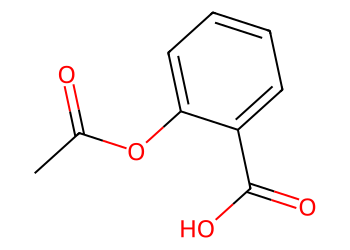

In [ ]:
# Let's demonstrate with Aspirin (Acetylsalicylic acid)
aspirin_smiles = "CC(=O)Oc1ccccc1C(=O)O"
aspirin_mol = Chem.MolFromSmiles(aspirin_smiles)

print(f"Input SMILES      : {aspirin_smiles}")
print(f"Canonical SMILES  : {Chem.MolToSmiles(aspirin_mol)}")
print(f"Formula           : {rdMolDescriptors.CalcMolFormula(aspirin_mol)}")
print(f"Total Atoms (all) : {aspirin_mol.GetNumAtoms()}")
print(f"Heavy Atoms (non-H): {aspirin_mol.GetNumHeavyAtoms()}")

# Render 2D depiction
Draw.MolToImage(aspirin_mol, size=(350, 250))

### 06. Atom-Level Structural Inspection

Every `Mol` object in RDKit is composed of `Atom` objects. We can query:
- Atomic index (`GetIdx()`)
- Element symbol (`GetSymbol()`) and atomic number (`GetAtomicNum()`)
- Formal charge (`GetFormalCharge()`)
- Hybridization state ($sp, sp^2, sp^3$) (`GetHybridization()`)
- Aromaticity (`GetIsAromatic()`)
- Degree (number of bonded neighbors) and implicit hydrogen count (`GetTotalNumHs()`)


In [ ]:
example_mol = data_clean.iloc[1]['mol'] # Fenfuram
print(f"Compound: {data_clean.iloc[1]['Compound ID']} | SMILES: {data_clean.iloc[1]['canonical_smiles']}")

atom_records = []
for atom in example_mol.GetAtoms():
    atom_records.append({
        "Idx": atom.GetIdx(),
        "Symbol": atom.GetSymbol(),
        "AtomicNum": atom.GetAtomicNum(),
        "Degree": atom.GetDegree(),
        "TotalHs": atom.GetTotalNumHs(),
        "Valence": atom.GetTotalValence(),
        "Charge": atom.GetFormalCharge(),
        "Hybridization": str(atom.GetHybridization()),
        "IsAromatic": atom.GetIsAromatic(),
        "IsInRing": atom.IsInRing()
    })

atom_df = pd.DataFrame(atom_records)
print(f"Total Heavy Atoms: {len(atom_df)}")
atom_df

Compound: Fenfuram | SMILES: Cc1occc1C(=O)Nc1ccccc1
Total Heavy Atoms: 15


,Idx,Symbol,AtomicNum,Degree,TotalHs,Valence,Charge,Hybridization,IsAromatic,IsInRing
0,0,C,6,1,3,4,0,SP3,False,False
1,1,C,6,3,0,4,0,SP2,True,True
2,2,O,8,2,0,2,0,SP2,True,True
3,3,C,6,2,1,4,0,SP2,True,True
4,4,C,6,2,1,4,0,SP2,True,True
5,5,C,6,3,0,4,0,SP2,True,True
6,6,C,6,3,0,4,0,SP2,False,False
7,7,O,8,1,0,2,0,SP2,False,False
8,8,N,7,2,1,3,0,SP2,False,False
9,9,C,6,3,0,4,0,SP2,True,True


### 07. Bond-Level Structural Inspection

Chemical bonds connect atom pairs. In RDKit, each `Bond` has:
- Bond type (`SINGLE`, `DOUBLE`, `TRIPLE`, `AROMATIC`)
- Bond order (1.0, 2.0, 3.0, 1.5)
- Conjugation flag (`GetIsConjugated()`)
- Ring membership (`IsInRing()`)
- Direction / stereochemical information


In [ ]:
#  Detailed Bond Table
bond_records = []
for bond in example_mol.GetBonds():
    bond_records.append({
        "BondIdx": bond.GetIdx(),
        "BeginAtom": f"{bond.GetBeginAtom().GetSymbol()}({bond.GetBeginAtomIdx()})",
        "EndAtom": f"{bond.GetEndAtom().GetSymbol()}({bond.GetEndAtomIdx()})",
        "BondType": str(bond.GetBondType()),
        "BondOrder": bond.GetBondTypeAsDouble(),
        "IsAromatic": bond.GetIsAromatic(),
        "IsConjugated": bond.GetIsConjugated(),
        "IsInRing": bond.IsInRing()
    })

bond_df = pd.DataFrame(bond_records)
print(f"Total Chemical Bonds: {len(bond_df)}")
bond_df.head(10)

Total Chemical Bonds: 16


,BondIdx,BeginAtom,EndAtom,BondType,BondOrder,IsAromatic,IsConjugated,IsInRing
0,0,C(0),C(1),SINGLE,1.0,False,False,False
1,1,C(1),O(2),AROMATIC,1.5,True,True,True
2,2,O(2),C(3),AROMATIC,1.5,True,True,True
3,3,C(3),C(4),AROMATIC,1.5,True,True,True
4,4,C(4),C(5),AROMATIC,1.5,True,True,True
5,5,C(5),C(6),SINGLE,1.0,False,True,False
6,6,C(6),O(7),DOUBLE,2.0,False,True,False
7,7,C(6),N(8),SINGLE,1.0,False,True,False
8,8,N(8),C(9),SINGLE,1.0,False,True,False
9,9,C(9),C(10),AROMATIC,1.5,True,True,True


### 08. Dataset Element Frequency Analysis

In medicinal chemistry, the distribution of elements gives immediate insight into chemical diversity. Organic drug molecules primarily consist of carbon, nitrogen, oxygen, sulfur, phosphorus, and halogens (F, Cl, Br, I).


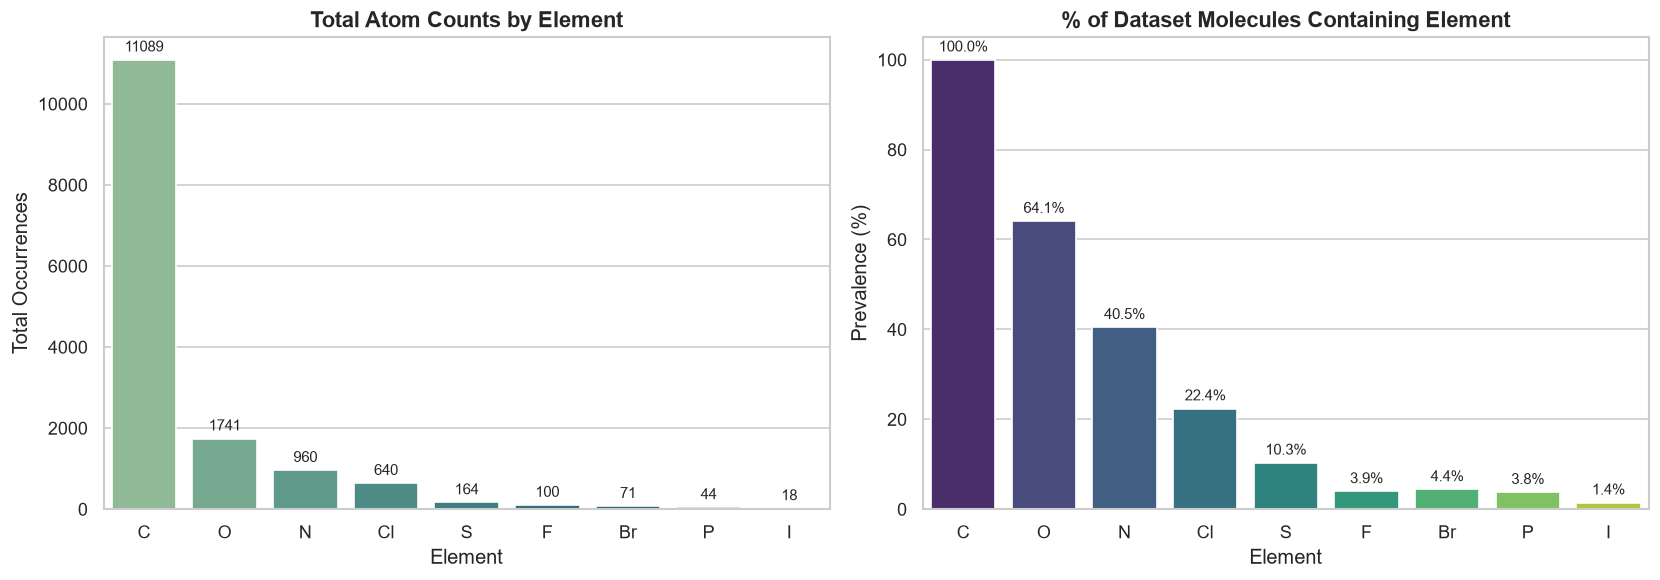

,Element,Total_Count,Molecules_Containing,Atom_Percentage,Molecule_Prevalence_%
0,C,11089,1117,74.789236,100.000000
1,O,1741,716,11.742092,64.100269
2,N,960,452,6.474675,40.465533
3,Cl,640,250,4.316450,22.381379
4,S,164,115,1.106090,10.295434
5,F,100,44,0.674445,3.939123
6,Br,71,49,0.478856,4.386750
7,P,44,42,0.296756,3.760072
8,I,18,16,0.121400,1.432408


In [ ]:
# Element Frequency Distribution Across Delaney Dataset
from collections import Counter

element_counts = Counter()
molecule_element_presence = Counter()

for mol in data_clean['mol']:
    elements_in_mol = [atom.GetSymbol() for atom in mol.GetAtoms()]
    element_counts.update(elements_in_mol)
    molecule_element_presence.update(set(elements_in_mol))

elem_df = pd.DataFrame({
    'Element': list(element_counts.keys()),
    'Total_Count': list(element_counts.values()),
    'Molecules_Containing': [molecule_element_presence[k] for k in element_counts.keys()]
})

total_atoms = elem_df['Total_Count'].sum()
total_mols = len(data_clean)
elem_df['Atom_Percentage'] = (elem_df['Total_Count'] / total_atoms) * 100
elem_df['Molecule_Prevalence_%'] = (elem_df['Molecules_Containing'] / total_mols) * 100
elem_df = elem_df.sort_values(by='Total_Count', ascending=False).reset_index(drop=True)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=elem_df, x='Element', y='Total_Count', ax=ax[0], palette='crest')
ax[0].set_title("Total Atom Counts by Element", fontsize=13, fontweight='bold')
ax[0].set_ylabel("Total Occurrences")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

sns.barplot(data=elem_df, x='Element', y='Molecule_Prevalence_%', ax=ax[1], palette='viridis')
ax[1].set_title("% of Dataset Molecules Containing Element", fontsize=13, fontweight='bold')
ax[1].set_ylabel("Prevalence (%)")
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

elem_df

### 09. 2D Coordinate Generation & Molecular Grid Visualization

To display molecules, 2D coordinates must be calculated. RDKit uses the **Distance Geometry and Depictor algorithm** (`rdDepictor.Compute2DCoords()`) to compute aesthetically pleasing, chemically standard 2D layouts.


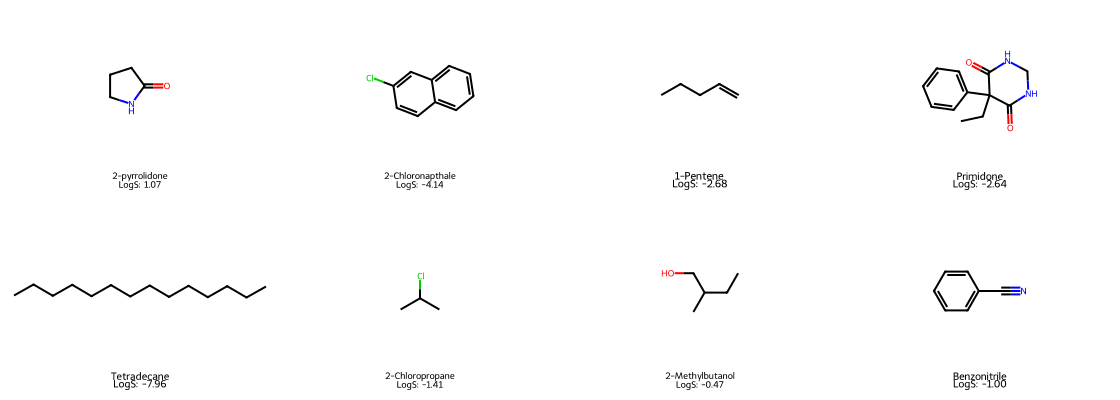

In [ ]:
# 2D Coordinates & Grid Visualization
# Compute 2D coordinates for all clean molecules
for mol in data_clean['mol']:
    rdDepictor.Compute2DCoords(mol)

# Select 8 diverse molecules for visualization
sample_mols = data_clean['mol'].iloc[10:18].tolist()
sample_legends = [
    f"{name[:16]}\nLogS: {logs:.2f}"
    for name, logs in zip(
        data_clean['Compound ID'].iloc[10:18],
        data_clean['measured log solubility in mols per litre'].iloc[10:18]
    )
]

img_grid = Draw.MolsToGridImage(
    sample_mols,
    molsPerRow=4,
    subImgSize=(280, 200),
    legends=sample_legends
)
img_grid


### 10. SMARTS Pattern Matching & Functional Group Highlighting

**SMARTS (Smiles Arbitrary Target Specification)** is a chemical query language that allows pattern matching against molecular substructures. 

Here we define SMARTS patterns for essential pharmacophoric groups and highlight them on a molecule:
- **Carboxylic Acid**: `[CX3](=O)[OX2H1]`
- **Hydroxyl**: `[OX2H]`
- **Carbonyl**: `[CX3]=[OX1]`
- **Amine (Primary/Secondary)**: `[NX3;H2,H1;!$(NC=O)]`
- **Aromatic Ring**: `c1ccccc1`


Analyzing Compound: Amigdalin
  • Hydroxyl (-OH)      : 7 match(es)
  • Nitrile (-C#N)      : 1 match(es)
  • Aromatic Ring       : 1 match(es)
  • Ether (-C-O-C-)     : 4 match(es)

Highlighting 7 atoms belonging to -OH groups...


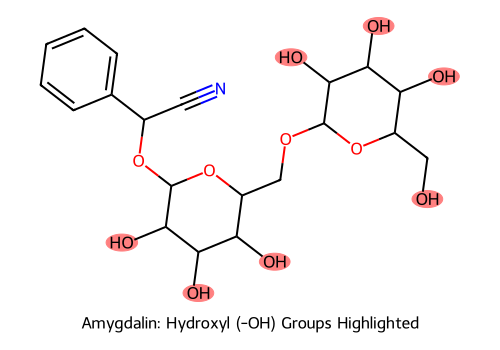

In [ ]:
# Amygdalin (Molecule 0 in dataset - complex polyhydroxy glucoside with nitrile)
mol_demo = data_clean.iloc[0]['mol']
print(f"Analyzing Compound: {data_clean.iloc[0]['Compound ID']}")

# Define SMARTS queries
smarts_patterns = {
    "Hydroxyl (-OH)": Chem.MolFromSmarts("[OX2H]"),
    "Nitrile (-C#N)": Chem.MolFromSmarts("[CX2]#[NX1]"),
    "Aromatic Ring": Chem.MolFromSmarts("c1ccccc1"),
    "Ether (-C-O-C-)": Chem.MolFromSmarts("[OD2]([#6])[#6]")
}

matches_summary = {}
for name, query in smarts_patterns.items():
    if query is not None:
        matches = mol_demo.GetSubstructMatches(query)
        matches_summary[name] = len(matches)
        print(f"  • {name:<20}: {len(matches)} match(es)")

# Highlight the Hydroxyl groups on Amygdalin
oh_matches = mol_demo.GetSubstructMatches(smarts_patterns["Hydroxyl (-OH)"])
highlight_atoms = [idx for match in oh_matches for idx in match]

print(f"\nHighlighting {len(highlight_atoms)} atoms belonging to -OH groups...")
Draw.MolToImage(
    mol_demo,
    size=(500, 350),
    highlightAtoms=highlight_atoms,
    legend="Amygdalin: Hydroxyl (-OH) Groups Highlighted"
)


### 11. Chirality and Stereochemistry

Stereoisomers possess identical connectivity but differ in 3D spatial arrangement. Chirality affects drug potency, toxicity, and metabolism (e.g., Thalidomide). RDKit identifies:
1. **Tetrahedral stereocenters** (R / S configuration via Cahn-Ingold-Prelog rules).
2. **Double bond stereochemistry** ($E$ / $Z$ or trans / cis).


Molecule: L-Threonine (C[C@H](O)[C@@H](N)C(=O)O)
Identified Stereocenters: [(1, 'S'), (3, 'R')]
  Atom 1 (C): CIP Configuration = S
  Atom 3 (C): CIP Configuration = R

E/Z Double Bond Isomers:
  trans-2-butene (E) SMILES: C/C=C/C
  cis-2-butene (Z)   SMILES: C/C=C\C


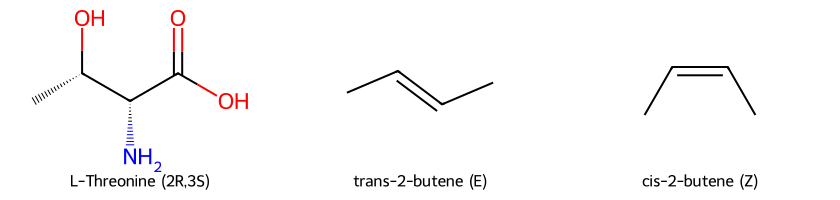

In [ ]:
# Test molecule with stereocenters: L-Threonine
threonine_smiles = "C[C@H](O)[C@@H](N)C(=O)O"
threonine_mol = Chem.MolFromSmiles(threonine_smiles)

# Detect chiral centers
chiral_centers = Chem.FindMolChiralCenters(threonine_mol, includeUnassigned=True)
print(f"Molecule: L-Threonine ({threonine_smiles})")
print(f"Identified Stereocenters: {chiral_centers}")
for idx, config in chiral_centers:
    atom = threonine_mol.GetAtomWithIdx(idx)
    print(f"  Atom {idx} ({atom.GetSymbol()}): CIP Configuration = {config}")

# E / Z Double Bond Isomerism
mol_trans = Chem.MolFromSmiles("C/C=C/C") # trans-2-butene (E)
mol_cis   = Chem.MolFromSmiles("C/C=C\C") # cis-2-butene (Z)

print("\nE/Z Double Bond Isomers:")
print(f"  trans-2-butene (E) SMILES: {Chem.MolToSmiles(mol_trans)}")
print(f"  cis-2-butene (Z)   SMILES: {Chem.MolToSmiles(mol_cis)}")

Draw.MolsToGridImage(
    [threonine_mol, mol_trans, mol_cis],
    molsPerRow=3,
    subImgSize=(280, 200),
    legends=["L-Threonine (2R,3S)", "trans-2-butene (E)", "cis-2-butene (Z)"]
)


### 12. Molecular Image Export Function (PNG & SVG)

To prepare graphics for publications, presentations, or web apps, we build a dedicated export utility function.


In [ ]:
# High-Resolution Molecular Image Exporter
def export_molecule_image(mol, filename="molecule_export.png", img_format="png", size=(500, 400)):
    """
    Export an RDKit Mol object as high-resolution PNG or vector SVG.
    """
    if img_format.lower() == "svg":
        from rdkit.Chem.Draw import rdMolDraw2D
        drawer = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        svg_text = drawer.GetDrawingText()
        with open(filename, "w", encoding="utf-8") as f:
            f.write(svg_text)
        print(f"✅ Exported SVG to: {filename}")
    else:
        img = Draw.MolToImage(mol, size=size)
        img.save(filename)
        print(f"✅ Exported PNG ({size[0]}x{size[1]}) to: {filename}")

# Test export
export_molecule_image(aspirin_mol, "aspirin_demo.png", img_format="png")

✅ Exported PNG (500x400) to: aspirin_demo.png


---
## Module 03 — Molecular Graph & Network Analysis

Molecules are naturally represented as **attributed mathematical graphs** $G = (V, E)$:
- **Vertices (Nodes) $V$**: Atoms, characterized by a node feature vector $\mathbf{x}_i$ (element, hybridization, charge, aromaticity).
- **Edges $E$**: Chemical bonds, characterized by an edge feature vector $\mathbf{e}_{ij}$ (bond type, conjugation, ring status).
- **Adjacency Matrix $A$**: An $N \times N$ matrix indicating atomic connectivity.

This graph representation is the **foundation for Graph Neural Networks (GNNs)** such as GCN, GAT, and SchNet in modern AI drug discovery!


In [ ]:
# Node Feature Extraction
def extract_node_features(mol):
    """
    Extract numerical feature vectors for all nodes (atoms) in a molecule.
    Ideal for feeding into PyTorch Geometric or DGL.
    """
    node_features = []
    for atom in mol.GetAtoms():
        features = [
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),
            atom.GetTotalNumHs(),
            int(atom.GetHybridization())
        ]
        node_features.append(features)
    
    return np.array(node_features, dtype=np.float32)

sample_mol = data_clean.iloc[1]['mol']
X_nodes = extract_node_features(sample_mol)
print(f"Molecule: {data_clean.iloc[1]['Compound ID']}")
print(f"Node feature matrix shape: {X_nodes.shape} (Atoms × Features)")
print("\nFirst 5 Atom Feature Vectors:")
print(X_nodes[:5])

Molecule: Fenfuram
Node feature matrix shape: (15, 7) (Atoms × Features)

First 5 Atom Feature Vectors:
[[6. 1. 0. 0. 0. 3. 4.]
 [6. 3. 0. 1. 1. 0. 3.]
 [8. 2. 0. 1. 1. 0. 3.]
 [6. 2. 0. 1. 1. 1. 3.]
 [6. 2. 0. 1. 1. 1. 3.]]


### 14. Edge Feature Extraction & Adjacency Matrices

Chemical bonds have distinct bond orders (Single=1.0, Double=2.0, Triple=3.0, Aromatic=1.5). We can construct:
1. **Unweighted Adjacency Matrix**: $A_{ij} = 1$ if atom $i$ is bonded to atom $j$, else $0$.
2. **Weighted Adjacency Matrix**: $W_{ij} = \text{BondOrder}(i, j)$ if bonded, else $0$.


Adjacency Matrix Size: 15 × 15


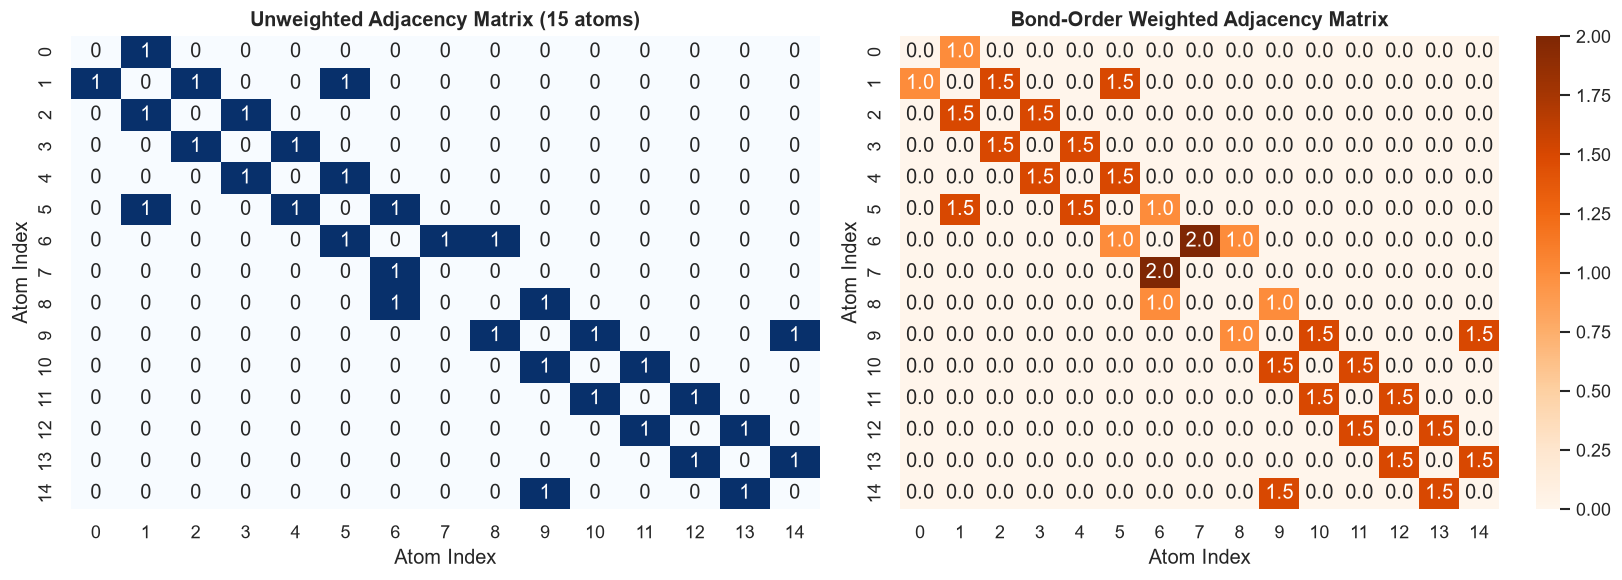

In [ ]:
# Unweighted Topological Adjacency Matrix
A_unweighted = Chem.GetAdjacencyMatrix(sample_mol)

# Weighted Adjacency Matrix
n_atoms = sample_mol.GetNumAtoms()
W_weighted = np.zeros((n_atoms, n_atoms), dtype=np.float32)

for bond in sample_mol.GetBonds():
    i = bond.GetBeginAtomIdx()
    j = bond.GetEndAtomIdx()
    order = bond.GetBondTypeAsDouble()
    W_weighted[i, j] = order
    W_weighted[j, i] = order

print(f"Adjacency Matrix Size: {n_atoms} × {n_atoms}")

# Heatmap visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(A_unweighted, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0])
ax[0].set_title(f"Unweighted Adjacency Matrix ({sample_mol.GetNumAtoms()} atoms)", fontsize=12, fontweight='bold')
ax[0].set_xlabel("Atom Index")
ax[0].set_ylabel("Atom Index")

sns.heatmap(W_weighted, annot=True, fmt=".1f", cmap="Oranges", cbar=True, ax=ax[1])
ax[1].set_title("Bond-Order Weighted Adjacency Matrix", fontsize=12, fontweight='bold')
ax[1].set_xlabel("Atom Index")
ax[1].set_ylabel("Atom Index")

plt.tight_layout()
plt.show()


### 15. Molecular Graph Visualization via NetworkX

We can convert any RDKit `Mol` into a `networkx.Graph` to compute graph invariants (diameter, degree centrality, clustering coefficient) and plot an interactive network layout!


NetworkX Graph: 15 Nodes, 16 Edges
Graph Diameter: 8
Average Degree: 2.13


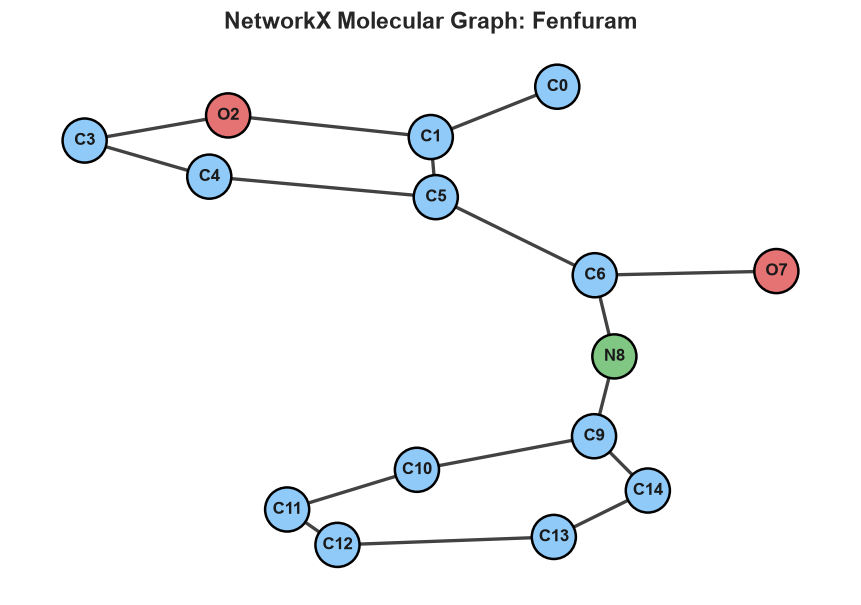

In [ ]:
# Converting RDKit Mol to NetworkX Graph & Rendering
def mol_to_nx_graph(mol):
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(
            atom.GetIdx(),
            symbol=atom.GetSymbol(),
            atomic_num=atom.GetAtomicNum(),
            is_aromatic=atom.GetIsAromatic()
        )
    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            weight=bond.GetBondTypeAsDouble(),
            bond_type=str(bond.GetBondType())
        )
    return G

G = mol_to_nx_graph(sample_mol)
print(f"NetworkX Graph: {G.number_of_nodes()} Nodes, {G.number_of_edges()} Edges")
print(f"Graph Diameter: {nx.diameter(G)}")
print(f"Average Degree: {np.mean([d for _, d in G.degree()]):.2f}")

# Color mapping by element
color_map = {'C': '#90CAF9', 'N': '#81C784', 'O': '#E57373', 'S': '#FFF176', 'Cl': '#BA68C8', 'F': '#4DD0E1'}
node_colors = [color_map.get(G.nodes[n]['symbol'], '#B0BEC5') for n in G.nodes()]
node_labels = {n: f"{G.nodes[n]['symbol']}{n}" for n in G.nodes()}

plt.figure(figsize=(9, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=2, edge_color='#424242')

plt.title(f"NetworkX Molecular Graph: {data_clean.iloc[1]['Compound ID']}", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()


---
## Module 04 — Molecular Properties & Descriptors

Molecular descriptors are numerical values that quantify chemical, electronic, and topological characteristics of molecules. They are the **primary inputs for QSAR (Quantitative Structure-Activity Relationship) modeling** and classical machine learning.

We categorize descriptors into:
1. **1D Descriptors**: Counts derived directly from molecular formula (MW, Heavy Atom Count, Molecular Formula).
2. **2D Descriptors**: Physicochemical and topological invariants computed from connectivity (LogP, TPSA, HBD, HBA, Rotatable Bonds, Rings, Fraction Csp3, Balaban J, Bertz Complexity).
3. **3D Descriptors**: Spatial properties computed from 3D conformers (Radius of Gyration, Asphericity, Eccentricity, Principal Moments of Inertia).


In [ ]:
# Step-by-Step 2D Physicochemical Descriptors
demo_mol = aspirin_mol # Aspirin
Chem.SanitizeMol(demo_mol)

print("🧪 PHYSICOCHEMICAL PROPERTIES (ASPIRIN):")
print("-" * 55)
print(f"  • Molecular Weight (MolWt)        : {Descriptors.MolWt(demo_mol):.3f} g/mol")
print(f"  • Exact Monoisotopic Mass         : {Descriptors.ExactMolWt(demo_mol):.4f} Da")
print(f"  • Octanol-Water Partition (LogP)   : {Crippen.MolLogP(demo_mol):.3f}")
print(f"  • Topological Polar Surface (TPSA) : {rdMolDescriptors.CalcTPSA(demo_mol):.2f} Å²")
print(f"  • Hydrogen Bond Donors (HBD)      : {Lipinski.NumHDonors(demo_mol)}")
print(f"  • Hydrogen Bond Acceptors (HBA)   : {Lipinski.NumHAcceptors(demo_mol)}")
print(f"  • Rotatable Bonds                 : {Lipinski.NumRotatableBonds(demo_mol)}")
print(f"  • Heavy Atom Count                : {demo_mol.GetNumHeavyAtoms()}")
print(f"  • Total Ring Count                : {rdMolDescriptors.CalcNumRings(demo_mol)}")
print(f"  • Aromatic Ring Count             : {rdMolDescriptors.CalcNumAromaticRings(demo_mol)}")
print(f"  • Fraction Csp3 (aliphatic carbon): {rdMolDescriptors.CalcFractionCSP3(demo_mol):.3f}")
print(f"  • Total Formal Charge             : {Chem.GetFormalCharge(demo_mol)}")
print(f"  • Molar Refractivity (MolMR)      : {Crippen.MolMR(demo_mol):.2f}")


🧪 PHYSICOCHEMICAL PROPERTIES (ASPIRIN):
-------------------------------------------------------
  • Molecular Weight (MolWt)        : 180.159 g/mol
  • Exact Monoisotopic Mass         : 180.0423 Da
  • Octanol-Water Partition (LogP)   : 1.310
  • Topological Polar Surface (TPSA) : 63.60 Å²
  • Hydrogen Bond Donors (HBD)      : 1
  • Hydrogen Bond Acceptors (HBA)   : 3
  • Rotatable Bonds                 : 2
  • Heavy Atom Count                : 13
  • Total Ring Count                : 1
  • Aromatic Ring Count             : 1
  • Fraction Csp3 (aliphatic carbon): 0.111
  • Total Formal Charge             : 0
  • Molar Refractivity (MolMR)      : 44.71


### 17. Advanced Topological Complexity & Shape Descriptors

- **Balaban J Index**: A topological distance-based index that measures molecular branching. It remains virtually constant as molecular size increases and is sensitive to cyclicity.
- **BertzCT Complexity**: An information-theoretic index measuring connectivity complexity and molecular symmetry. High values indicate highly intricate, synthetic structures.
- **Chi Connectivity Indices ($\chi$)**: Randić and Kier-Hall topological indices representing degree of branchiness and atomic valence states.
- **Kappa Shape Indices ($\kappa_1, \kappa_2, \kappa_3$)**: Quantify spatial shape and cyclicity relative to ideal linear and star graphs.
- **Labute ASA**: Approximate Surface Area calculated from atomic radii and connectivity.


In [ ]:
# Computing Advanced Topological & Graph Descriptors
print("📐 ADVANCED TOPOLOGICAL & SHAPE INDICES (ASPIRIN):")
print("-" * 55)
print(f"  • Balaban J Index      : {Descriptors.BalabanJ(demo_mol):.4f}")
print(f"  • Bertz Complexity     : {Descriptors.BertzCT(demo_mol):.2f}")
print(f"  • Labute ASA           : {rdMolDescriptors.CalcLabuteASA(demo_mol):.2f} Å²")
print(f"  • Chi0v (Valence)      : {Descriptors.Chi0v(demo_mol):.4f}")
print(f"  • Chi1v                : {Descriptors.Chi1v(demo_mol):.4f}")
print(f"  • Kappa 1 (Shape)      : {Descriptors.Kappa1(demo_mol):.4f}")
print(f"  • Kappa 2 (Branching)  : {Descriptors.Kappa2(demo_mol):.4f}")
print(f"  • Kappa 3 (Spatial)    : {Descriptors.Kappa3(demo_mol):.4f}")


📐 ADVANCED TOPOLOGICAL & SHAPE INDICES (ASPIRIN):
-------------------------------------------------------
  • Balaban J Index      : 3.0435
  • Bertz Complexity     : 343.22
  • Labute ASA           : 74.76 Å²
  • Chi0v (Valence)      : 6.9814
  • Chi1v                : 3.6175
  • Kappa 1 (Shape)      : 9.2496
  • Kappa 2 (Branching)  : 3.7093
  • Kappa 3 (Spatial)    : 2.2974


### 18. 3D Conformer Generation & 3D Shape Descriptors

To calculate true 3D spatial properties:
1. Add explicit hydrogens (`Chem.AddHs()`).
2. Generate initial 3D coordinates using Distance Geometry (`AllChem.EmbedMolecule()`).
3. Optimize coordinates using the **MMFF94 force field** (`AllChem.MMFFOptimizeMolecule()`).
4. Compute 3D descriptors: **Radius of Gyration**, **Asphericity**, and **Eccentricity**.


In [ ]:
# 3D Conformer Embedding & 3D Descriptors
# Generate 3D conformer for Aspirin
mol_3d = Chem.AddHs(demo_mol)
embed_status = AllChem.EmbedMolecule(mol_3d, randomSeed=42)
opt_status = AllChem.MMFFOptimizeMolecule(mol_3d, maxIters=500)

print(f"3D Embedding Success : {embed_status == 0}")
print(f"MMFF94 Optimization  : {'Converged' if opt_status == 0 else 'Completed'}")

# Compute 3D Shape Descriptors
rg = rdMolDescriptors.CalcRadiusOfGyration(mol_3d)
asph = rdMolDescriptors.CalcAsphericity(mol_3d)
ecc = rdMolDescriptors.CalcEccentricity(mol_3d)
pmi1 = rdMolDescriptors.CalcPBF(mol_3d) # Plane of Best Fit

print("\n🌐 3D SHAPE PROPERTIES:")
print("-" * 45)
print(f"  • Radius of Gyration : {rg:.4f} Å (measures mass distribution around center)")
print(f"  • Asphericity        : {asph:.4f} (0 = sphere, 1 = rod-like/linear)")
print(f"  • Eccentricity       : {ecc:.4f} (0 = sphere, 1 = planar disk)")
print(f"  • Plane of Best Fit  : {pmi1:.4f} Å (deviation from 2D plane)")

3D Embedding Success : True
MMFF94 Optimization  : Converged

🌐 3D SHAPE PROPERTIES:
---------------------------------------------
  • Radius of Gyration : 2.4283 Å (measures mass distribution around center)
  • Asphericity        : 0.1973 (0 = sphere, 1 = rod-like/linear)
  • Eccentricity       : 0.8865 (0 = sphere, 1 = planar disk)
  • Plane of Best Fit  : 0.3826 Å (deviation from 2D plane)


### 19. Dataset-Wide Molecular Descriptor Matrix (`descriptor_df`)

Now, let us calculate our full suite of 2D descriptors across **all 1,117 molecules** in our clean dataset to build `descriptor_df`.


In [ ]:
# Dataset-Wide Descriptor Matrix Generation
def calculate_all_descriptors(mol):
    """Calculates a comprehensive 2D descriptor profile for a given molecule."""
    if mol is None:
        return {}
    return {
        "MW": Descriptors.MolWt(mol),
        "ExactMass": Descriptors.ExactMolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "Rings": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "FormalCharge": Chem.GetFormalCharge(mol),
        "MolMR": Crippen.MolMR(mol),
        "BalabanJ": Descriptors.BalabanJ(mol),
        "BertzCT": Descriptors.BertzCT(mol),
        "LabuteASA": rdMolDescriptors.CalcLabuteASA(mol),
        "Kappa1": Descriptors.Kappa1(mol),
        "Kappa2": Descriptors.Kappa2(mol)
    }

print("⚙️ Computing descriptors across all 1,117 dataset molecules...")
descriptor_records = [calculate_all_descriptors(m) for m in data_clean['mol']]
descriptor_df = pd.DataFrame(descriptor_records, index=data_clean.index)

print(f"✅ Descriptor DataFrame generated: {descriptor_df.shape[0]} molecules × {descriptor_df.shape[1]} descriptors")
descriptor_df.head()


⚙️ Computing descriptors across all 1,117 dataset molecules...


✅ Descriptor DataFrame generated: 1117 molecules × 18 descriptors


,MW,ExactMass,LogP,TPSA,HBD,HBA,RotatableBonds,HeavyAtoms,Rings,AromaticRings,FractionCSP3,FormalCharge,MolMR,BalabanJ,BertzCT,LabuteASA,Kappa1,Kappa2
0,457.432,457.158411,-3.10802,202.32,7,12,7,32,3,1,0.650000,0,102.2816,1.654937,759.662938,182.935327,24.903474,10.926356
1,201.225,201.078979,2.84032,42.24,1,2,2,15,2,2,0.083333,0,57.8402,2.148162,459.484175,87.724095,9.522160,4.002882
2,152.237,152.120115,2.87800,17.07,0,1,4,11,0,0,0.500000,0,48.4860,3.625760,171.311799,68.806046,10.150000,5.899351
3,278.354,278.109550,6.29940,0.00,0,0,0,22,5,5,0.000000,0,96.4660,2.041379,1071.547817,128.158061,11.762233,4.315741
4,84.143,84.003371,1.74810,0.00,0,1,0,5,1,1,0.000000,0,24.3190,3.125000,60.124818,35.071766,2.912766,1.221050


---
## Module 05 — Molecular Fingerprints

A **molecular fingerprint** encodes the presence or absence of specific substructural features into a fixed-length binary bit string (e.g. 1024 or 2048 bits). Fingerprints allow rapid similarity searching across millions of compounds in seconds!

### 🔍 Types of Molecular Fingerprints:
1. **Circular Fingerprints (Morgan / ECFP)**: Derived from the Morgan algorithm. Captures circular atomic neighborhoods up to radius $R$ (Radius 2 corresponds to **ECFP4**, Radius 3 to **ECFP6**). This is the gold standard in machine learning!
2. **MACCS Keys**: 166 predefined structural fragments (e.g., presence of S-S bond, halogen, 6-membered ring).
3. **RDKit Fingerprint**: Daylight-style topological paths through the molecular graph up to 7 bonds.
4. **Atom-Pair Fingerprint**: Encodes pairs of atoms and the shortest topological path between them.
5. **Topological Torsion Fingerprint**: Encodes linear sequences of 4 bonded atoms.


In [ ]:
# Morgan (ECFP4) Fingerprint Generation & NumPy Conversion

# Use modern RDKit rdFingerprintGenerator API
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Generate fingerprint for Aspirin
demo_fp = morgan_gen.GetFingerprint(aspirin_mol)

print(f"Fingerprint Type : Morgan Circular (ECFP4 equivalent)")
print(f"Bit Vector Length: {demo_fp.GetNumBits()} bits")
print(f"Total 'On' Bits  : {demo_fp.GetNumOnBits()} bits active")
print(f"Bit Density      : {demo_fp.GetNumOnBits() / demo_fp.GetNumBits() * 100:.2f}%")

# Convert ExplicitBitVect to NumPy array for Machine Learning
def fp_to_numpy(bit_vect):
    arr = np.zeros((bit_vect.GetNumBits(),), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(bit_vect, arr)
    return arr

demo_arr = fp_to_numpy(demo_fp)
print(f"NumPy Array Shape: {demo_arr.shape} | First 20 bits: {demo_arr[:20]}")

# Batch compute Morgan fingerprints for all molecules in dataset
data_clean['morgan_fp'] = [morgan_gen.GetFingerprint(m) for m in data_clean['mol']]
X_morgan = np.vstack([fp_to_numpy(fp) for fp in data_clean['morgan_fp']])
print(f"✅ Full Dataset Morgan Matrix Shape: {X_morgan.shape}")


Fingerprint Type : Morgan Circular (ECFP4 equivalent)
Bit Vector Length: 2048 bits
Total 'On' Bits  : 24 bits active
Bit Density      : 1.17%
NumPy Array Shape: (2048,) | First 20 bits: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
✅ Full Dataset Morgan Matrix Shape: (1117, 2048)


### 21. Fingerprint Bit Visualization: Tracing Bits Back to Atoms

A frequent student question is: *"What does bit 1024 actually mean chemically?"* 

With RDKit, we can extract the exact circular atomic fragment that activated any specific bit and draw it on the molecule!


Aspirin has 24 active bits. Active bit IDs (first 6): [389, 456, 650, 695, 807, 909]
Rendering substructures activating Bits:


[19:41:06] DEPRECATION WARNING: please use MorganGenerator


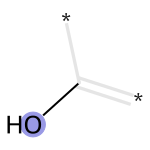

In [ ]:
# Visualizing Substructural Fragments That Activate Fingerprint Bits

# Extract bit info mapping: bitId -> [(atom_idx, radius), ...]
bit_info = {}
fp_with_info = morgan_gen.GetFingerprint(aspirin_mol, additionalOutput=rdFingerprintGenerator.AdditionalOutput())
# Using Chem.rdMolDescriptors to capture exact bit info dictionary
bit_info_dict = {}
fp_explained = rdMolDescriptors.GetMorganFingerprintAsBitVect(aspirin_mol, radius=2, nBits=2048, bitInfo=bit_info_dict)

on_bits = list(bit_info_dict.keys())
print(f"Aspirin has {len(on_bits)} active bits. Active bit IDs (first 6): {on_bits[:6]}")

# Pick first two active bits and draw the molecular fragment
fig_bits = []
bit_legends = []
for bit_id in on_bits[:3]:
    atom_idx, rad = bit_info_dict[bit_id][0]
    fig = Draw.DrawMorganBit(aspirin_mol, bit_id, bit_info_dict)
    fig_bits.append(fig)
    bit_legends.append(f"Bit {bit_id} (Center: Atom {atom_idx}, Rad: {rad})")

print("Rendering substructures activating Bits:")
# Display first bit visualization
Draw.DrawMorganBit(aspirin_mol, on_bits[0], bit_info_dict)

### 22. Comparative Fingerprint Analysis

Let us compare the 5 major fingerprint families across our dataset:
1. **Morgan (ECFP4)** (2048 bits)
2. **MACCS Keys** (166 bits)
3. **RDKit Topological** (2048 bits)
4. **Atom-Pair** (2048 bits)
5. **Topological Torsion** (2048 bits)


In [ ]:
# Comparative Fingerprint Generators
from rdkit.Chem import MACCSkeys

rdkit_fp_gen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
atom_pair_gen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
torsion_gen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048)

fp_comparison = []

# 1. Morgan
fp_morgan = morgan_gen.GetFingerprint(aspirin_mol)
fp_comparison.append({
    "Fingerprint Type": "Morgan (ECFP4)",
    "Total Bits": fp_morgan.GetNumBits(),
    "On Bits (Aspirin)": fp_morgan.GetNumOnBits(),
    "Sparsity (%)": (1.0 - (fp_morgan.GetNumOnBits() / fp_morgan.GetNumBits())) * 100,
    "Primary Use Case": "General QSAR / Deep Learning"
})

# 2. MACCS
fp_maccs = MACCSkeys.GenMACCSKeys(aspirin_mol)
fp_comparison.append({
    "Fingerprint Type": "MACCS Keys (166)",
    "Total Bits": fp_maccs.GetNumBits(),
    "On Bits (Aspirin)": fp_maccs.GetNumOnBits(),
    "Sparsity (%)": (1.0 - (fp_maccs.GetNumOnBits() / fp_maccs.GetNumBits())) * 100,
    "Primary Use Case": "Drug-likeness / Fast Filter"
})

# 3. RDKit Topological
fp_rdkit = rdkit_fp_gen.GetFingerprint(aspirin_mol)
fp_comparison.append({
    "Fingerprint Type": "RDKit Topological",
    "Total Bits": fp_rdkit.GetNumBits(),
    "On Bits (Aspirin)": fp_rdkit.GetNumOnBits(),
    "Sparsity (%)": (1.0 - (fp_rdkit.GetNumOnBits() / fp_rdkit.GetNumBits())) * 100,
    "Primary Use Case": "Substructure Screening"
})

# 4. Atom Pair
fp_atompair = atom_pair_gen.GetFingerprint(aspirin_mol)
fp_comparison.append({
    "Fingerprint Type": "Atom Pair",
    "Total Bits": fp_atompair.GetNumBits(),
    "On Bits (Aspirin)": fp_atompair.GetNumOnBits(),
    "Sparsity (%)": (1.0 - (fp_atompair.GetNumOnBits() / fp_atompair.GetNumBits())) * 100,
    "Primary Use Case": "Shape and Scaffold Hopping"
})

# 5. Topological Torsion
fp_torsion = torsion_gen.GetFingerprint(aspirin_mol)
fp_comparison.append({
    "Fingerprint Type": "Topological Torsion",
    "Total Bits": fp_torsion.GetNumBits(),
    "On Bits (Aspirin)": fp_torsion.GetNumOnBits(),
    "Sparsity (%)": (1.0 - (fp_torsion.GetNumOnBits() / fp_torsion.GetNumBits())) * 100,
    "Primary Use Case": "Topological Conformation"
})

pd.DataFrame(fp_comparison)


,Fingerprint Type,Total Bits,On Bits (Aspirin),Sparsity (%),Primary Use Case
0,Morgan (ECFP4),2048,24,98.828125,General QSAR / Deep Learning
1,MACCS Keys (166),167,21,87.425150,Drug-likeness / Fast Filter
2,RDKit Topological,2048,354,82.714844,Substructure Screening
3,Atom Pair,2048,68,96.679688,Shape and Scaffold Hopping
4,Topological Torsion,2048,18,99.121094,Topological Conformation


---
## Module 06 — Molecular Similarity & Virtual Screening

The **Similar Property Principle** (Johnson & Maggiora, 1990) states:
> *"Structurally similar molecules tend to have similar physical, chemical, and biological properties."*

In virtual screening, when a lead molecule exhibits active biological binding, chemists search chemical libraries for structural analogues.

### 📐 Similarity Coefficients for Binary Fingerprints:
Given two bit vectors $A$ and $B$, where $a$ is on-bits in $A$, $b$ is on-bits in $B$, and $c$ is common bits ($A \cap B$):
- **Tanimoto (Jaccard) Similarity**:
  $$T(A, B) = \frac{c}{a + b - c}$$
  Range: $[0, 1]$. In medicinal chemistry, $T \ge 0.70$ or $0.85$ is frequently considered a high-confidence analogue.
- **Dice Similarity**:
  $$D(A, B) = \frac{2c}{a + b}$$
- **Cosine Similarity**:
  $$S_{\cos}(A, B) = \frac{c}{\sqrt{a \cdot b}}$$
- **Euclidean Distance**:
  $$d_E(A, B) = \sqrt{a + b - 2c}$$


In [ ]:
# Pairwise Similarity Calculation Across Multiple Metrics

# Compare Aspirin vs Ibuprofen vs Paracetamol
aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
paracetamol = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")
ibuprofen = Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)C(C)C(=O)O")

fp_asp = morgan_gen.GetFingerprint(aspirin)
fp_para = morgan_gen.GetFingerprint(paracetamol)
fp_ibu = morgan_gen.GetFingerprint(ibuprofen)

pairs = [
    ("Aspirin vs Paracetamol", fp_asp, fp_para),
    ("Aspirin vs Ibuprofen", fp_asp, fp_ibu),
    ("Paracetamol vs Ibuprofen", fp_para, fp_ibu)
]

sim_results = []
for name, fp1, fp2 in pairs:
    sim_results.append({
        "Pair": name,
        "Tanimoto": DataStructs.TanimotoSimilarity(fp1, fp2),
        "Dice": DataStructs.DiceSimilarity(fp1, fp2),
        "Cosine": DataStructs.CosineSimilarity(fp1, fp2),
        "Sokal": DataStructs.SokalSimilarity(fp1, fp2)
    })

pd.DataFrame(sim_results)


,Pair,Tanimoto,Dice,Cosine,Sokal
0,Aspirin vs Paracetamol,0.222222,0.363636,0.365148,0.125000
1,Aspirin vs Ibuprofen,0.195122,0.326531,0.326599,0.108108
2,Paracetamol vs Ibuprofen,0.184211,0.311111,0.313050,0.101449


### 24. All-Against-All Similarity Matrix & Heatmap

Let us compute the pairwise similarity matrix for a subset of dataset molecules to inspect chemical clustering and diversity.


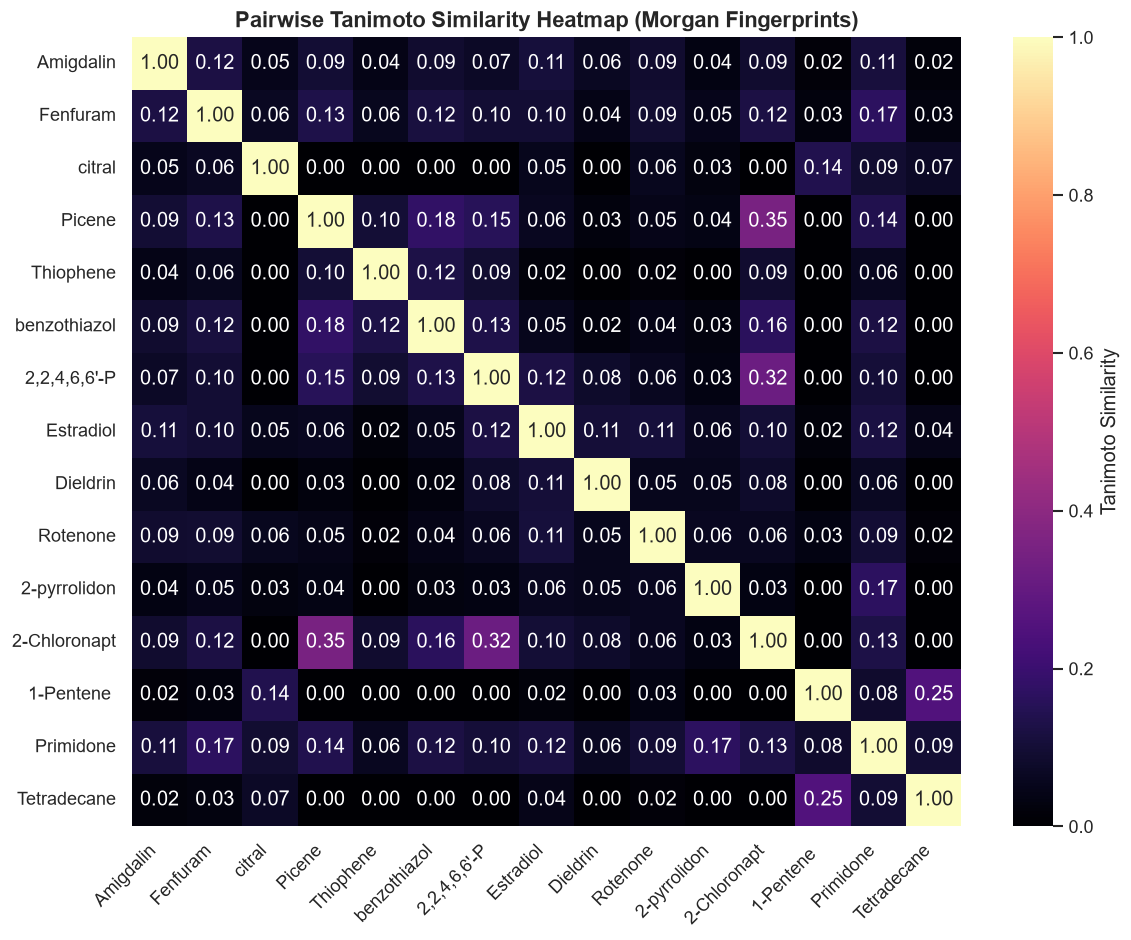

In [ ]:
# Pairwise Tanimoto Similarity Matrix & Heatmap

subset_mols = data_clean['mol'].iloc[:15].tolist()
subset_names = [f"{n[:12]}" for n in data_clean['Compound ID'].iloc[:15]]
subset_fps = [morgan_gen.GetFingerprint(m) for m in subset_mols]

n = len(subset_fps)
sim_matrix = np.zeros((n, n), dtype=np.float32)

for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(subset_fps[i], subset_fps[j])

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=subset_names,
    yticklabels=subset_names,
    cmap="magma",
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Tanimoto Similarity'}
)
plt.title("Pairwise Tanimoto Similarity Heatmap (Morgan Fingerprints)", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 25. Virtual Screening Engine: Query Search & Nearest Neighbors

Here, we build a complete **Virtual Screening function**:
Given any query SMILES (e.g., Paracetamol or a newly synthesized lead), search the entire dataset of 1,117 molecules, rank by Tanimoto similarity, filter by a similarity threshold ($T \ge 0.40$), and display the top nearest structural neighbors with their chemical structures!


🎯 Query: Paracetamol (Acetaminophen)
Top 4 Structural Neighbours Found in Delaney Dataset:
  • p-Hydroxyacetanilide   | Tanimoto: 1.0000 | Measured LogS: -1.03
  • p-Fluoroacetanilide    | Tanimoto: 0.6400 | Measured LogS: -1.78
  • p-Bromoacetanilide     | Tanimoto: 0.6400 | Measured LogS: -3.08
  • p-Chloroacetanilide    | Tanimoto: 0.6400 | Measured LogS: -2.84


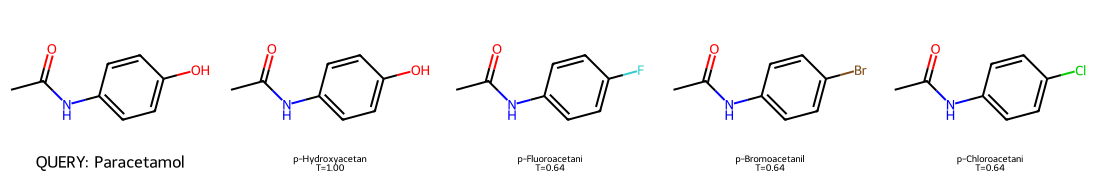

In [ ]:
# Virtual Screening & Nearest Neighbors Function

def virtual_screening(query_smiles, dataset_df, top_k=5, threshold=0.20):
    """
    Performs virtual screening across dataset against a query molecule.
    """
    query_mol = Chem.MolFromSmiles(query_smiles)
    if query_mol is None:
        raise ValueError("Invalid query SMILES string!")
    
    query_fp = morgan_gen.GetFingerprint(query_mol)
    
    # Fast bulk Tanimoto similarity in C++
    all_fps = dataset_df['morgan_fp'].tolist()
    scores = DataStructs.BulkTanimotoSimilarity(query_fp, all_fps)
    
    results_df = dataset_df.copy()
    results_df['Tanimoto_Similarity'] = scores
    
    # Filter and rank
    matches = results_df[results_df['Tanimoto_Similarity'] >= threshold].sort_values(
        by='Tanimoto_Similarity', ascending=False
    ).head(top_k)
    
    return query_mol, matches

# Test virtual screening with Paracetamol
q_mol, top_matches = virtual_screening("CC(=O)Nc1ccc(O)cc1", data_clean, top_k=4)

print(f"🎯 Query: Paracetamol (Acetaminophen)")
print(f"Top {len(top_matches)} Structural Neighbours Found in Delaney Dataset:")
for idx, row in top_matches.iterrows():
    print(f"  • {row['Compound ID']:<22} | Tanimoto: {row['Tanimoto_Similarity']:.4f} | Measured LogS: {row['measured log solubility in mols per litre']:.2f}")

# Render Top Matches in Grid
match_mols = [q_mol] + top_matches['mol'].tolist()
match_legends = ["QUERY: Paracetamol"] + [
    f"{r['Compound ID'][:15]}\nT={r['Tanimoto_Similarity']:.2f}"
    for _, r in top_matches.iterrows()
]

Draw.MolsToGridImage(match_mols, molsPerRow=len(match_mols), subImgSize=(220, 180), legends=match_legends)


---
## Module 07 — Drug-Likeness & Rule of Five Screening

**Drug-likeness** evaluates whether a compound has structural and physicochemical properties consistent with known orally administered human drugs.

### 💊 Lipinski's Rule of Five (Ro5):
Formulated by Christopher Lipinski in 1997 at Pfizer:
1. **Molecular Weight (MW)** $\le 500\text{ Da}$
2. **Lipophilicity (LogP)** $\le 5.0$
3. **Hydrogen Bond Donors (HBD)** $\le 5$ (sum of OH and NH groups)
4. **Hydrogen Bond Acceptors (HBA)** $\le 10$ (sum of O and N atoms)

> **Medicinal Chemistry Note**: A compound with $\le 1$ violation is generally acceptable for oral drug candidacy. $\ge 2$ violations indicate likely oral absorption or bioavailability hurdles.

### 📐 Veber's Additional Rules (GlaxoSmithKline, 2002):
- **Rotatable Bonds** $\le 10$ (prevents excessive entropic penalty upon receptor binding)
- **Topological Polar Surface Area (TPSA)** $\le 140\text{ Å}^2$ (ensures cell membrane permeation)

### 📈 Quantitative Estimate of Drug-likeness (QED):
Published by Bickerton et al. (Nature Chemistry, 2012). Rather than rigid binary pass/fail cutoffs, QED combines continuous desirability functions for 8 descriptors into a single score from **0.0 (completely non-drug-like) to 1.0 (ideal drug-like)**.


In [ ]:
# Lipinski Rule of 5 and Veber Rule Screening Function
def evaluate_drug_likeness(mol):
    """Evaluates Lipinski Rule of 5, Veber rules, and calculates QED score."""
    if mol is None:
        return {}
    
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    rot_bonds = Lipinski.NumRotatableBonds(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    
    violations = {
        "MW_violation": mw > 500,
        "LogP_violation": logp > 5.0,
        "HBD_violation": hbd > 5,
        "HBA_violation": hba > 10,
        "RotBonds_violation": rot_bonds > 10,
        "TPSA_violation": tpsa > 140.0
    }
    
    ro5_violations = sum([
        violations["MW_violation"],
        violations["LogP_violation"],
        violations["HBD_violation"],
        violations["HBA_violation"]
    ])
    
    return {
        "Lipinski_Violations": ro5_violations,
        "Lipinski_Pass": ro5_violations <= 1,
        "Veber_Pass": (not violations["RotBonds_violation"]) and (not violations["TPSA_violation"]),
        "QED": QED.qed(mol)
    }

# Apply to all molecules in dataset
ro5_results = pd.DataFrame([evaluate_drug_likeness(m) for m in data_clean['mol']], index=data_clean.index)
data_clean['Lipinski_Violations'] = ro5_results['Lipinski_Violations']
data_clean['Lipinski_Pass'] = ro5_results['Lipinski_Pass']
data_clean['Veber_Pass'] = ro5_results['Veber_Pass']
data_clean['QED'] = ro5_results['QED']

print(f"📊 LIPINSKI RULE OF FIVE SCREENING SUMMARY (N={len(data_clean)}):")
print("-" * 60)
print(data_clean['Lipinski_Violations'].value_counts().sort_index().rename(lambda v: f"{v} Violations").to_string())
print(f"\nTotal passing Lipinski (≤ 1 violation): {data_clean['Lipinski_Pass'].sum()} ({data_clean['Lipinski_Pass'].mean()*100:.1f}%)")
print(f"Total passing Veber Rules              : {data_clean['Veber_Pass'].sum()} ({data_clean['Veber_Pass'].mean()*100:.1f}%)")
print(f"Average QED Score                      : {data_clean['QED'].mean():.3f} (Min: {data_clean['QED'].min():.3f}, Max: {data_clean['QED'].max():.3f})")


📊 LIPINSKI RULE OF FIVE SCREENING SUMMARY (N=1117):
------------------------------------------------------------
Lipinski_Violations
0 Violations    1009
1 Violations      96
2 Violations      10
3 Violations       2

Total passing Lipinski (≤ 1 violation): 1105 (98.9%)
Total passing Veber Rules              : 1090 (97.6%)
Average QED Score                      : 0.553 (Min: 0.146, Max: 0.934)


### 27. Drug-Likeness Radar / Spider Chart

Radar charts provide an immediate visual diagnostic of a molecule's physicochemical profile compared to optimal oral drug property boundaries!


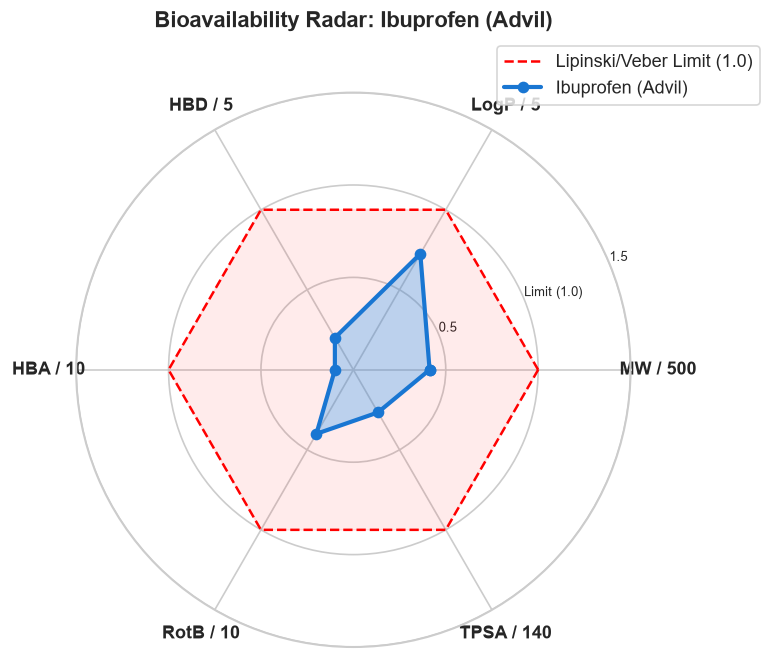

In [ ]:
# Radar Chart of Drug-Likeness Parameters
def plot_drug_likeness_radar(mol, compound_name="Molecule"):
    """Plots a 6-parameter drug-likeness radar chart with Lipinski boundaries."""
    props = {
        "MW / 500": min(Descriptors.MolWt(mol) / 500.0, 1.5),
        "LogP / 5": max(min((Crippen.MolLogP(mol) + 2) / 7.0, 1.5), 0.0),
        "HBD / 5": min(Lipinski.NumHDonors(mol) / 5.0, 1.5),
        "HBA / 10": min(Lipinski.NumHAcceptors(mol) / 10.0, 1.5),
        "RotB / 10": min(Lipinski.NumRotatableBonds(mol) / 10.0, 1.5),
        "TPSA / 140": min(rdMolDescriptors.CalcTPSA(mol) / 140.0, 1.5)
    }
    
    categories = list(props.keys())
    values = list(props.values())
    values += values[:1] # complete the loop
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    
    # Boundary threshold (1.0)
    ax.plot(angles, [1.0] * len(angles), color='red', linestyle='--', linewidth=1.5, label='Lipinski/Veber Limit (1.0)')
    ax.fill(angles, [1.0] * len(angles), color='red', alpha=0.08)
    
    # Molecule values
    ax.plot(angles, values, color='#1976D2', linewidth=2.5, marker='o', label=compound_name)
    ax.fill(angles, values, color='#2196F3', alpha=0.3)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
    ax.set_yticks([0.5, 1.0, 1.5])
    ax.set_yticklabels(['0.5', 'Limit (1.0)', '1.5'], fontsize=8)
    ax.set_ylim(0, 1.5)
    
    plt.title(f"Bioavailability Radar: {compound_name}", size=13, fontweight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
    plt.show()

# Plot radar for Ibuprofen
plot_drug_likeness_radar(ibuprofen, "Ibuprofen (Advil)")


---
## Module 08 — Dataset-Level Cheminformatics & Exploratory Analysis

In this module, we assemble our **Master Summary DataFrame (`summary_df`)** combining:
- Experimental target aqueous solubility (`measured log solubility in mols per litre`)
- ESOL predicted solubility
- All 18 computed molecular descriptors
- Drug-likeness pass/fail flags and QED scores

We then perform **exploratory data analysis (EDA)**: property distributions, correlation matrices, chemical space outlier detection, and **Principal Component Analysis (PCA)**.


In [ ]:
# Master Summary DataFrame Construction
summary_df = pd.concat([
    data_clean[['Compound ID', 'smiles', 'canonical_smiles', 'measured log solubility in mols per litre', 'ESOL predicted log solubility in mols per litre']],
    descriptor_df,
    data_clean[['Lipinski_Violations', 'Lipinski_Pass', 'Veber_Pass', 'QED']]
], axis=1)

# Clean column alias for convenient plotting
summary_df = summary_df.rename(columns={
    'measured log solubility in mols per litre': 'Measured_LogS',
    'ESOL predicted log solubility in mols per litre': 'ESOL_Predicted_LogS'
})

print(f"✅ Master Summary DataFrame constructed: {summary_df.shape[0]} rows × {summary_df.shape[1]} columns")
summary_df[['Compound ID', 'MW', 'LogP', 'TPSA', 'Measured_LogS', 'QED', 'Lipinski_Pass']].head()


✅ Master Summary DataFrame constructed: 1117 rows × 27 columns


,Compound ID,MW,LogP,TPSA,Measured_LogS,QED,Lipinski_Pass
0,Amigdalin,457.432,-3.10802,202.32,-0.77,0.217518,False
1,Fenfuram,201.225,2.84032,42.24,-3.30,0.811283,True
2,citral,152.237,2.87800,17.07,-2.06,0.343706,True
3,Picene,278.354,6.29940,0.00,-7.87,0.291526,True
4,Thiophene,84.143,1.74810,0.00,-1.33,0.448927,True


### 29. Descriptor Distribution Multi-Panel Visualization

Let us examine the distributions of key molecular descriptors across the Delaney chemical library.


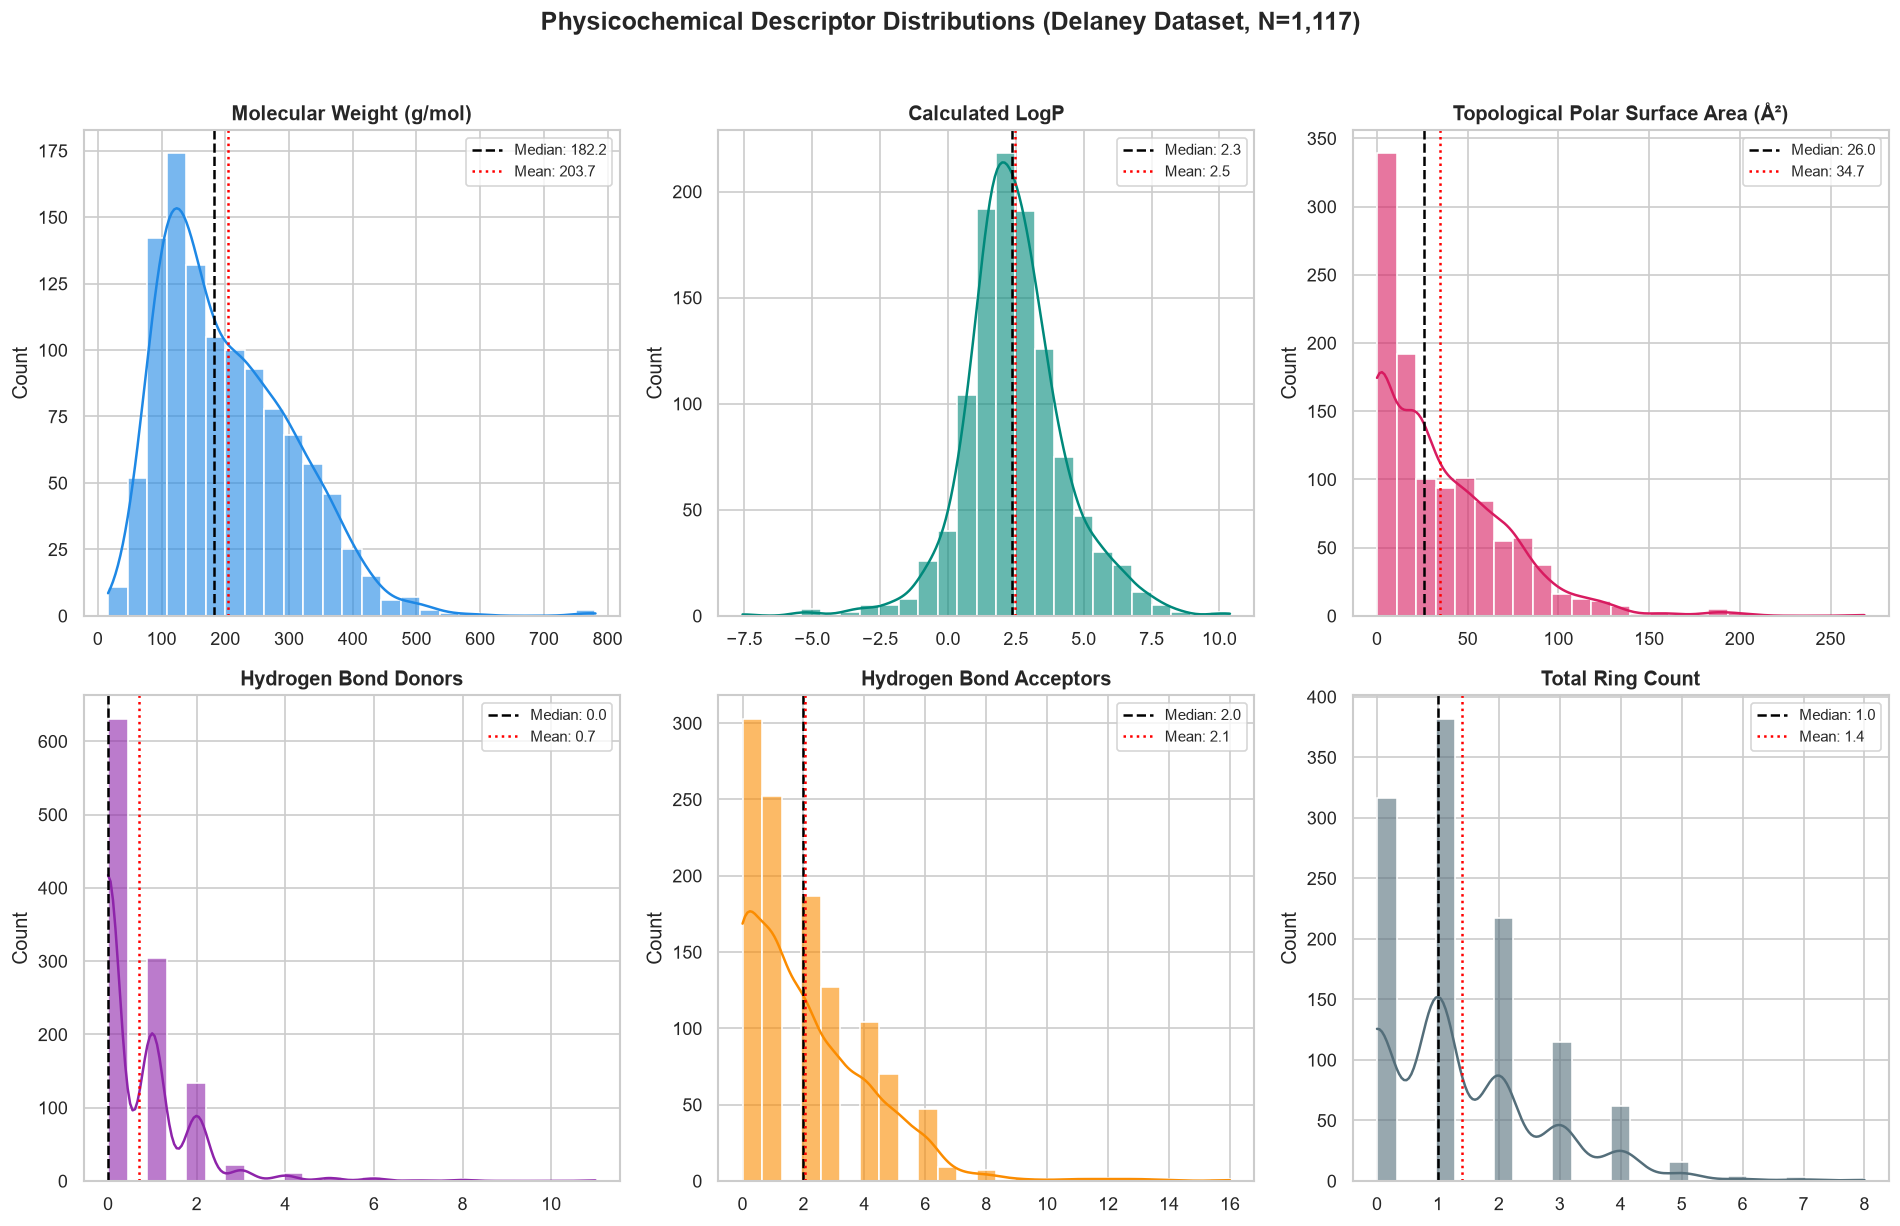

In [ ]:
# 6-Panel Descriptor Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
descriptors_to_plot = [
    ('MW', 'Molecular Weight (g/mol)', '#1E88E5'),
    ('LogP', 'Calculated LogP', '#00897B'),
    ('TPSA', 'Topological Polar Surface Area (Å²)', '#D81B60'),
    ('HBD', 'Hydrogen Bond Donors', '#8E24AA'),
    ('HBA', 'Hydrogen Bond Acceptors', '#FB8C00'),
    ('Rings', 'Total Ring Count', '#546E7A')
]

for ax, (col, title, color) in zip(axes.flatten(), descriptors_to_plot):
    sns.histplot(summary_df[col], kde=True, ax=ax, color=color, bins=25, alpha=0.6)
    median_val = summary_df[col].median()
    mean_val = summary_df[col].mean()
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
    ax.axvline(mean_val, color='red', linestyle=':', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.legend(fontsize=9)

plt.suptitle("Physicochemical Descriptor Distributions (Delaney Dataset, N=1,117)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 30. Property Correlations & The Hydrophobic Effect on Solubility

One of the cornerstone principles of pharmaceutical chemistry is that **lipophilicity (LogP) is inversely correlated with aqueous solubility ($\log S$)**. As molecules become more hydrophobic, water molecules form an ordered hydration cage (entropic penalty), making dissolution less energetically favorable.


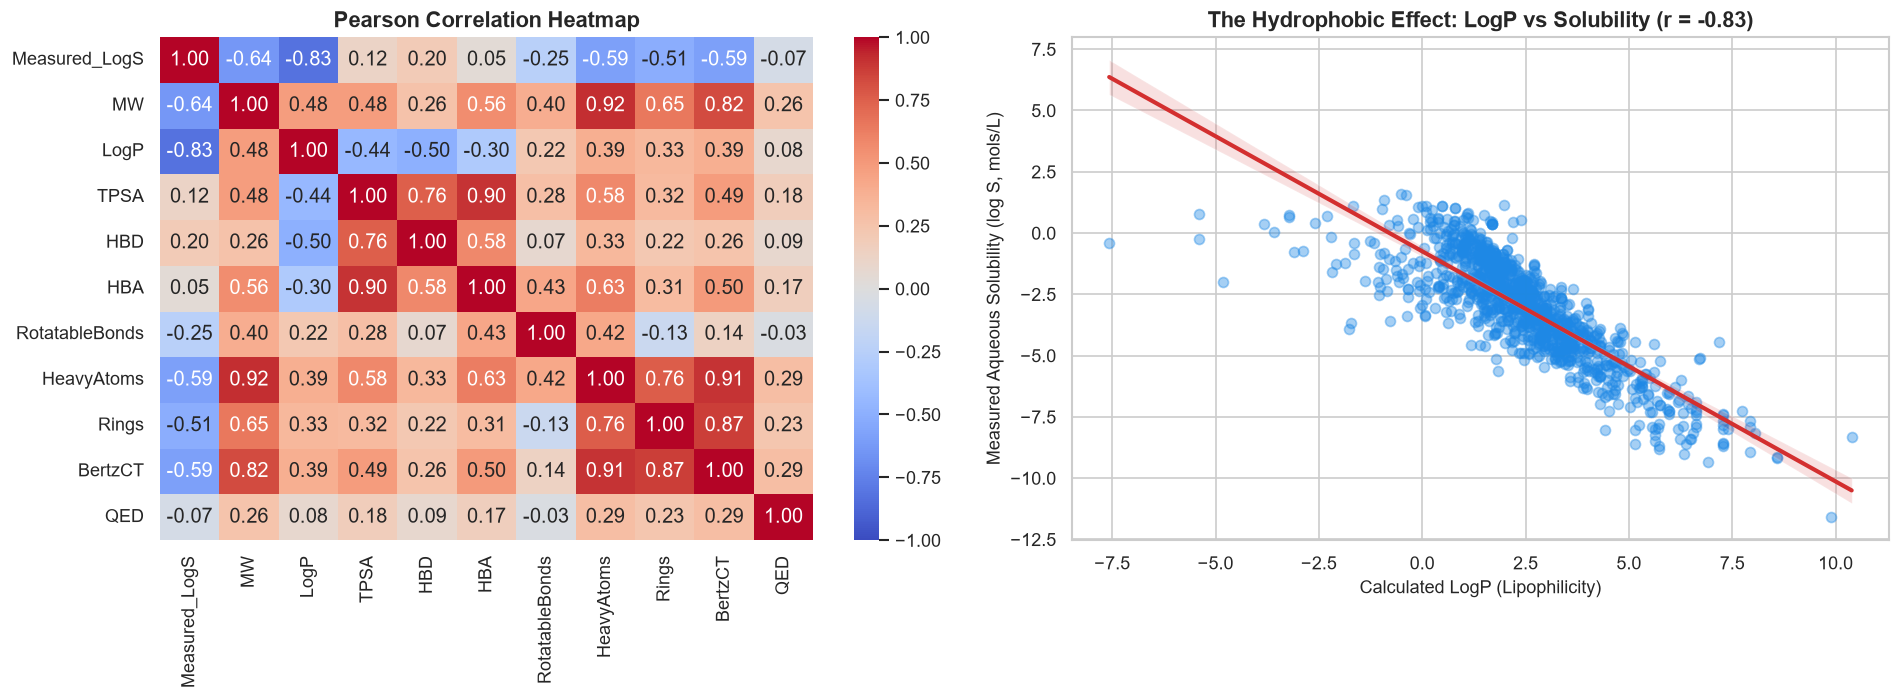

Strongest linear correlation with aqueous solubility: LogP (r = -0.827)


In [ ]:
# Correlation Matrix Heatmap & LogP vs LogS Regression
corr_cols = ['Measured_LogS', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'HeavyAtoms', 'Rings', 'BertzCT', 'QED']
corr_matrix = summary_df[corr_cols].corr()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Correlation Matrix Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar=True,
    ax=ax[0]
)
ax[0].set_title("Pearson Correlation Heatmap", fontsize=13, fontweight='bold')

# Subplot 2: The Hydrophobic Effect (LogP vs Measured LogS)
sns.regplot(
    data=summary_df,
    x='LogP',
    y='Measured_LogS',
    ax=ax[1],
    scatter_kws={'alpha': 0.4, 'color': '#1E88E5'},
    line_kws={'color': '#D32F2F', 'linewidth': 2.5}
)
r_val = summary_df['LogP'].corr(summary_df['Measured_LogS'])
ax[1].set_title(f"The Hydrophobic Effect: LogP vs Solubility (r = {r_val:.2f})", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Calculated LogP (Lipophilicity)", fontsize=11)
ax[1].set_ylabel("Measured Aqueous Solubility (log S, mols/L)", fontsize=11)

plt.tight_layout()
plt.show()

print(f"Strongest linear correlation with aqueous solubility: LogP (r = {r_val:.3f})")


### 31. Outlier Detection in Chemical Space

Outliers in chemical datasets can indicate:
1. Highly unusual chemotypes or macrocycles.
2. Exotic structures with extreme molecular weights or charge states.
3. Potential measurement errors or experimental anomalies.

Here, we employ the **Interquartile Range (IQR) rule**:
$$\text{Outlier} = x < (Q_1 - 1.5 \times \text{IQR}) \quad \text{or} \quad x > (Q_3 + 1.5 \times \text{IQR})$$


🚨 Total Multi-Parameter Chemical Outliers Detected: 15

Top 5 Extreme Chemical Outliers:


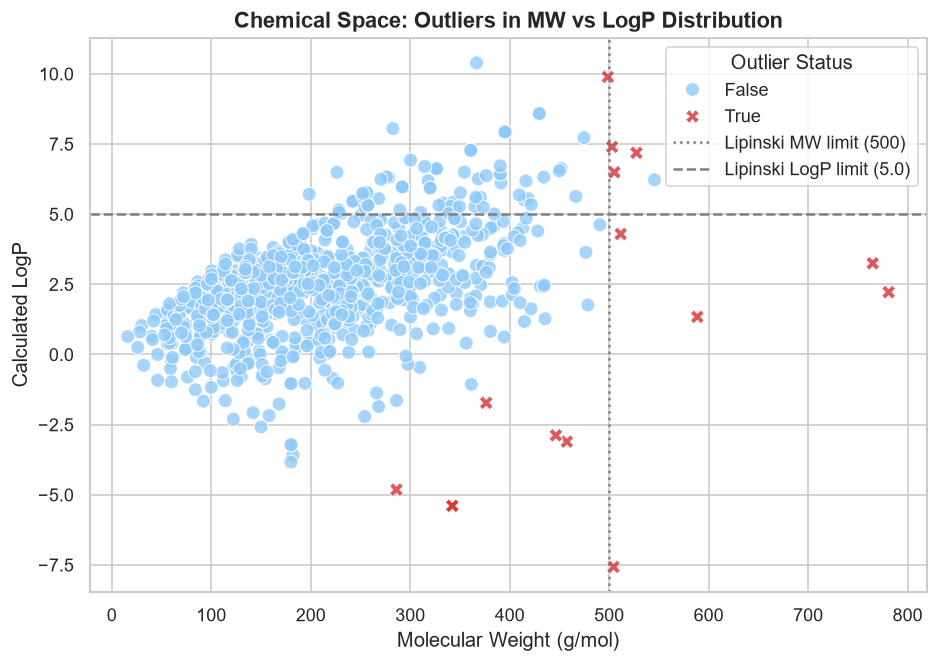

In [ ]:
# Statistical IQR-Based Outlier Detection
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_df = pd.DataFrame(index=summary_df.index)
for col in ['MW', 'LogP', 'TPSA', 'HeavyAtoms']:
    outlier_df[f"{col}_outlier"] = find_iqr_outliers(summary_df[col])

# Composite Outlier Score = sum of individual outlier flags
summary_df['Outlier_Score'] = outlier_df.sum(axis=1)
summary_df['Is_Outlier'] = summary_df['Outlier_Score'] >= 2

extreme_molecules = summary_df[summary_df['Is_Outlier']].sort_values(by='Outlier_Score', ascending=False)
print(f"🚨 Total Multi-Parameter Chemical Outliers Detected: {len(extreme_molecules)}")
print("\nTop 5 Extreme Chemical Outliers:")
extreme_molecules[['Compound ID', 'canonical_smiles', 'MW', 'LogP', 'TPSA', 'Outlier_Score']].head()

# Visualize Outliers on MW vs LogP
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=summary_df,
    x='MW',
    y='LogP',
    hue='Is_Outlier',
    palette={False: '#90CAF9', True: '#D32F2F'},
    style='Is_Outlier',
    markers={False: 'o', True: 'X'},
    s=70,
    alpha=0.8
)
plt.title("Chemical Space: Outliers in MW vs LogP Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Molecular Weight (g/mol)")
plt.ylabel("Calculated LogP")
plt.axvline(500, color='gray', linestyle=':', label='Lipinski MW limit (500)')
plt.axhline(5.0, color='gray', linestyle='--', label='Lipinski LogP limit (5.0)')
plt.legend(title="Outlier Status")
plt.show()


### 32. Chemical Space Visualization via Principal Component Analysis (PCA)

Because each molecule is described by 18 continuous descriptors, we can use **Principal Component Analysis (PCA)** to project this high-dimensional chemical space into 2 intuitive dimensions!


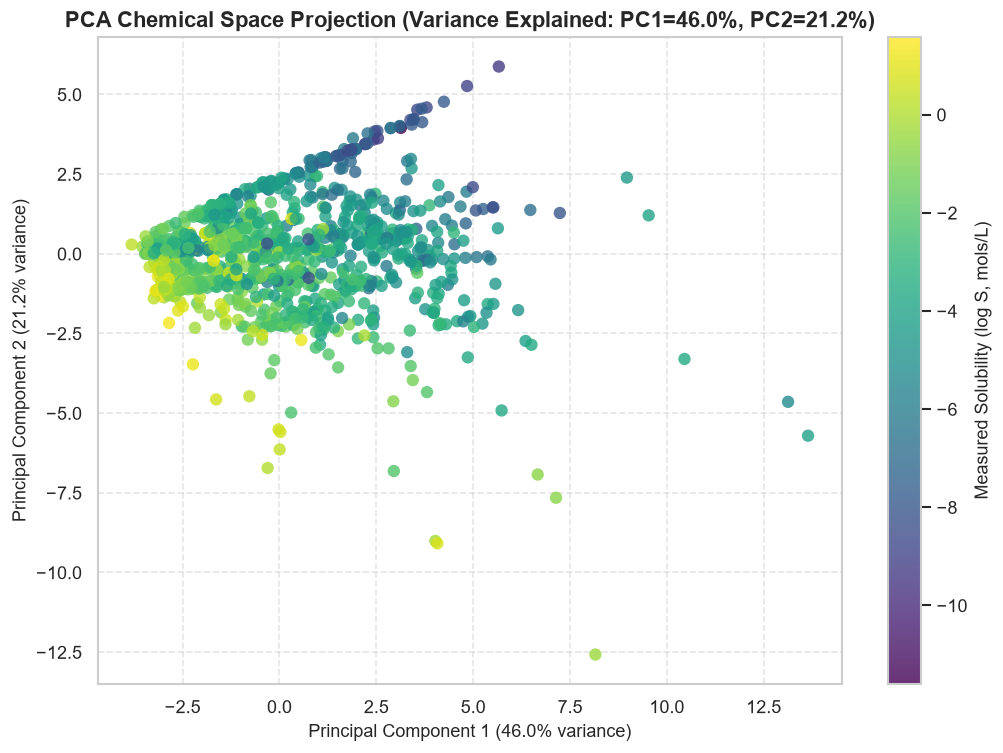

In [ ]:
# PCA Projection of Chemical Space

# Select continuous descriptor columns
pca_features = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'HeavyAtoms', 'Rings', 'AromaticRings', 'FractionCSP3', 'MolMR', 'BertzCT', 'BalabanJ']
X_desc = summary_df[pca_features].values

# Standardize features (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_desc)

# Fit PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

summary_df['PC1'] = X_pca[:, 0]
summary_df['PC2'] = X_pca[:, 1]

# Plot Chemical Space
plt.figure(figsize=(10, 7))
sc = plt.scatter(
    summary_df['PC1'],
    summary_df['PC2'],
    c=summary_df['Measured_LogS'],
    cmap='viridis',
    s=55,
    alpha=0.8,
    edgecolors='none'
)
cbar = plt.colorbar(sc)
cbar.set_label("Measured Solubility (log S, mols/L)", fontsize=11)

plt.title(f"PCA Chemical Space Projection (Variance Explained: PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}%)", fontsize=13, fontweight='bold')
plt.xlabel(f"Principal Component 1 ({var_exp[0]*100:.1f}% variance)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({var_exp[1]*100:.1f}% variance)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


---
## Module 09 — Capstone Application: The Interactive Molecule Explorer

Now, we bring everything we have built together into a complete, object-oriented application: the **`MoleculeExplorer`**.

### 🌟 Features of `MoleculeExplorer`:
1. **Universal Input**: Takes any SMILES string or looks up a compound from the dataset.
2. **Chemical Validation**: Validates SMILES and reports errors cleanly.
3. **2D Depiction**: Generates clean, aesthetic 2D coordinates and depictions.
4. **Physicochemical Profiler**: Computes MW, LogP, TPSA, HBD, HBA, RotBonds, Heavy Atoms, Rings, and QED.
5. **Drug-Likeness Diagnostic**: Evaluates Lipinski's Rule of 5 and Veber's rules with human-readable explanations.
6. **Virtual Screening / Analogue Finder**: Scans our chemical database and returns the top structural neighbors with Tanimoto scores.
7. **Report Exporter**: Exports the entire profile to **JSON**, **CSV**, or **PNG image**.


In [ ]:
# The MoleculeExplorer Class Implementation

class MoleculeExplorer:
    """
    Interactive Cheminformatics Application to explore, profile, 
    evaluate drug-likeness, and perform virtual screening on any molecule.
    """
    def __init__(self, dataset_df=None):
        self.dataset = dataset_df if dataset_df is not None else pd.DataFrame()
        self.morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
        
    def profile(self, smiles_or_name):
        """Generates a comprehensive chemical and drug-likeness profile."""
        # Check if name is in dataset
        if smiles_or_name in self.dataset['Compound ID'].values:
            row = self.dataset[self.dataset['Compound ID'] == smiles_or_name].iloc[0]
            smiles = row['canonical_smiles']
            name = smiles_or_name
        else:
            smiles = smiles_or_name
            name = "Custom Query Molecule"
            
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"❌ Invalid SMILES string: '{smiles}'")
            
        rdDepictor.Compute2DCoords(mol)
        
        # Calculate properties
        mw = Descriptors.MolWt(mol)
        logp = Crippen.MolLogP(mol)
        tpsa = rdMolDescriptors.CalcTPSA(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)
        rot_b = Lipinski.NumRotatableBonds(mol)
        heavy_atoms = mol.GetNumHeavyAtoms()
        rings = rdMolDescriptors.CalcNumRings(mol)
        qed_val = QED.qed(mol)
        formula = rdMolDescriptors.CalcMolFormula(mol)
        
        # Lipinski & Veber
        ro5_violations = sum([mw > 500, logp > 5.0, hbd > 5, hba > 10])
        veber_pass = (tpsa <= 140.0) and (rot_b <= 10)
        
        profile_data = {
            "Compound Name": name,
            "SMILES": Chem.MolToSmiles(mol),
            "Formula": formula,
            "Molecular Weight": f"{mw:.2f} g/mol",
            "LogP (Lipophilicity)": f"{logp:.2f}",
            "TPSA": f"{tpsa:.1f} Å²",
            "H-Bond Donors (HBD)": hbd,
            "H-Bond Acceptors (HBA)": hba,
            "Rotatable Bonds": rot_b,
            "Heavy Atoms": heavy_atoms,
            "Ring Count": rings,
            "QED Score": f"{qed_val:.3f}",
            "Lipinski Violations": ro5_violations,
            "Lipinski Pass (≤1)": "✅ PASS" if ro5_violations <= 1 else "❌ FAIL",
            "Veber Rules": "✅ PASS" if veber_pass else "❌ FAIL"
        }
        
        return {
            "mol": mol,
            "summary": profile_data,
            "raw_values": {
                "MW": mw, "LogP": logp, "TPSA": tpsa, "HBD": hbd, "HBA": hba, "RotB": rot_b, "QED": qed_val
            }
        }
    
    def display_dashboard(self, smiles_or_name):
        """Displays an elegant, unified visual dashboard."""
        res = self.profile(smiles_or_name)
        mol = res["mol"]
        summary = res["summary"]
        
        print("=" * 65)
        print(f"🔬 MOLECULE EXPLORER DASHBOARD: {summary['Compound Name']}")
        print("=" * 65)
        
        for k, v in summary.items():
            if k != "Compound Name":
                print(f"  {k:<26}: {v}")
        print("=" * 65)
        
        # Display 2D image
        return Draw.MolToImage(mol, size=(450, 300), legend=f"{summary['Compound Name']} ({summary['Formula']})")
    
    def find_analogues(self, smiles_or_name, top_k=3):
        """Virtual screening to find nearest structural analogues in the dataset."""
        if len(self.dataset) == 0:
            print("⚠️ No dataset loaded for analogue search.")
            return
            
        res = self.profile(smiles_or_name)
        q_fp = self.morgan_gen.GetFingerprint(res["mol"])
        
        all_fps = self.dataset['morgan_fp'].tolist()
        scores = DataStructs.BulkTanimotoSimilarity(q_fp, all_fps)
        
        df_copy = self.dataset.copy()
        df_copy['Tanimoto'] = scores
        matches = df_copy.sort_values(by='Tanimoto', ascending=False).head(top_k)
        
        print(f"\n🔍 Top {top_k} Structural Analogues in Delaney Dataset:")
        for _, r in matches.iterrows():
            print(f"  • {r['Compound ID']:<22} | Tanimoto: {r['Tanimoto']:.4f} | Solubility: {r['measured log solubility in mols per litre']:.2f}")
            
        return matches

print("✅ MoleculeExplorer class compiled successfully!")


✅ MoleculeExplorer class compiled successfully!


### 34. Live Demonstration: Profiling Blockbuster Drugs

Let us test our `MoleculeExplorer` application on several real-world active pharmaceutical ingredients (APIs):
1. **Aspirin** (Analgesic / Anti-inflammatory)
2. **Ibuprofen** (NSAID)
3. **Paracetamol** (Analgesic)
4. **Caffeine** (CNS Stimulant)


🔬 MOLECULE EXPLORER DASHBOARD: Custom Query Molecule
  SMILES                    : CC(=O)Oc1ccccc1C(=O)O
  Formula                   : C9H8O4
  Molecular Weight          : 180.16 g/mol
  LogP (Lipophilicity)      : 1.31
  TPSA                      : 63.6 Å²
  H-Bond Donors (HBD)       : 1
  H-Bond Acceptors (HBA)    : 3
  Rotatable Bonds           : 2
  Heavy Atoms               : 13
  Ring Count                : 1
  QED Score                 : 0.550
  Lipinski Violations       : 0
  Lipinski Pass (≤1)        : ✅ PASS
  Veber Rules               : ✅ PASS


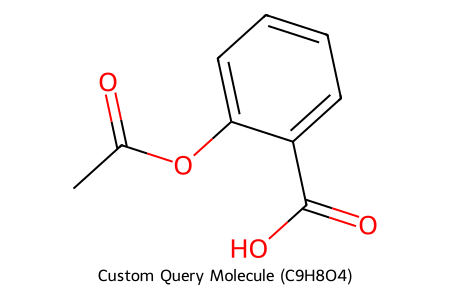

In [ ]:
# Initialize explorer with our cleaned dataset
explorer = MoleculeExplorer(dataset_df=data_clean)

# Test 1: Aspirin
explorer.display_dashboard("CC(=O)Oc1ccccc1C(=O)O")

🔬 MOLECULE EXPLORER DASHBOARD: Custom Query Molecule
  SMILES                    : Cn1c(=O)c2c(ncn2C)n(C)c1=O
  Formula                   : C8H10N4O2
  Molecular Weight          : 194.19 g/mol
  LogP (Lipophilicity)      : -1.03
  TPSA                      : 61.8 Å²
  H-Bond Donors (HBD)       : 0
  H-Bond Acceptors (HBA)    : 3
  Rotatable Bonds           : 0
  Heavy Atoms               : 14
  Ring Count                : 2
  QED Score                 : 0.538
  Lipinski Violations       : 0
  Lipinski Pass (≤1)        : ✅ PASS
  Veber Rules               : ✅ PASS


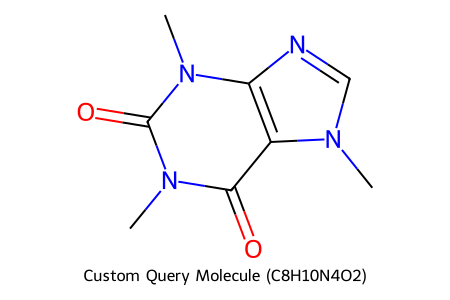

In [ ]:
# Test 2: Caffeine
caffeine_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"
explorer.display_dashboard(caffeine_smiles)


🔍 Top 4 Structural Analogues in Delaney Dataset:
  • Isobutylbenzene        | Tanimoto: 0.5000 | Solubility: -4.12
  • 1-Phenylethanol        | Tanimoto: 0.2812 | Solubility: -0.92
  • Isoproturon            | Tanimoto: 0.2750 | Solubility: -3.54
  • diphenamid             | Tanimoto: 0.2703 | Solubility: -2.98


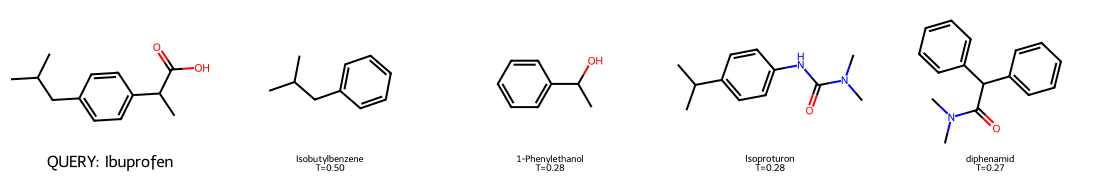

In [ ]:
# Test 3: Virtual Screening for Nearest Analogues of Ibuprofen
ibu_matches = explorer.find_analogues("CC(C)Cc1ccc(cc1)C(C)C(=O)O", top_k=4)

# Render Ibuprofen + Top matches
query_mol = Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)C(C)C(=O)O")
match_mols = [query_mol] + ibu_matches['mol'].tolist()
legends = ["QUERY: Ibuprofen"] + [f"{r['Compound ID'][:15]}\nT={r['Tanimoto']:.2f}" for _, r in ibu_matches.iterrows()]

Draw.MolsToGridImage(match_mols, molsPerRow=len(match_mols), subImgSize=(220, 180), legends=legends)

---
## 🎓 Course Summary & What We Accomplished

Congratulations on completing this hands-on **Cheminformatics Masterclass**! Let us recap the major skills and concepts mastered:

1. **Chemical Representation**: Mastered SMILES strings, RDKit `Mol` objects, canonicalization, valence validation, and chemical deduplication.
2. **Molecular Graphs**: Deconstructed chemical structures into nodes (atoms) and edges (bonds), extracted feature matrices, and rendered network layouts with NetworkX.
3. **Descriptors & 3D Chemistry**: Computed 2D physicochemical properties, topological complexity indices (BalabanJ, BertzCT), and 3D conformer shape descriptors.
4. **Fingerprints**: Generated circular Morgan (ECFP) fingerprints, explored bit vectors in NumPy, and visually traced specific bits back to atomic substructures.
5. **Similarity & Virtual Screening**: Implemented Tanimoto, Dice, and Cosine similarity metrics, computed similarity heatmaps, and screened libraries for structural analogues.
6. **Drug-Likeness**: Applied Lipinski's Rule of Five, Veber's rules, continuous QED scores, and plotted bioavailability radar charts.
7. **Dataset Analysis & Chemical Space**: Analyzed the Delaney solubility dataset, uncovered the hydrophobic effect on solubility, detected statistical outliers, and visualized chemical space with PCA.
8. **End-to-End Application**: Built an object-oriented `MoleculeExplorer` capstone tool ready for real-world research and web deployment.

---
### 🚀 Next Steps for Your Journey:
- **Graph Neural Networks (GNNs)**: Use the node and edge feature extraction pipelines from Module 03 with PyTorch Geometric (`torch_geometric`).
- **QSAR Machine Learning**: Train an XGBoost or Random Forest regressor to predict aqueous solubility ($\log S$) from our `descriptor_df` and Morgan fingerprints!
- **Target Profiling**: Query ChEMBL and PubChem to predict protein target binding affinities.
